# Hyperparameter Tuning + Feature Engineering: Grid Search, Pipelines, and Leakage Detection

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb09_tuning_feature_engineering_project_baseline_instructor.ipynb)

---

> **🎯 nb09 = the toolkit closer.** By the end of today, you will hold the full mid-course toolkit — every concept (bias–variance, overfitting vs underfitting, leakage, regression vs classification, the curse of dimensionality), every sklearn primitive (`Pipeline`, `ColumnTransformer`, `Ridge`/`Lasso`/`LogisticRegression`, `cross_val_score`, `GridSearchCV`/`RandomizedSearchCV`), and every decision rule (CI-overlap, "fit inside the pipeline", "test set stays locked"). **Section C of today's notebook is your one-page consolidated recap** of everything nb01–nb09 has built — keep it close as a reference for any future analysis.

---


## Learning Objectives

By the end of this notebook, you will be able to:

1. Run `GridSearchCV` and `RandomizedSearchCV` on known models and read `cv_results_` as a table of nb08-style CV runs
2. Apply the 95% confidence-interval overlap rule from nb08 to pick the simplest model among the top candidates in `cv_results_`
3. Build a `ColumnTransformer` that handles both categorical and numeric features inside a single `Pipeline`
4. Use `FunctionTransformer` to embed domain-specific feature engineering (ratios, bins) inside the pipeline without leakage
5. Detect a data-leakage bug in a provided pipeline by comparing CV scores before and after the fix
6. Explain why every feature-engineering step must live inside the pipeline that `cross_val_score` or `GridSearchCV` evaluates

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**, one at the end of each big section. Please complete them before submitting your notebook.

---

## 💼 Why This Matters: From One Knob to a Dial (and a Leaky Pipeline to Fix)

Two business cases are on your desk today — one returning from earlier notebooks, one brand new.

**Section A — HomeValue Analytics + MedScreen.** In nb05 you fit Ridge regression on California Housing across a few hand-picked $\alpha$ values — enough to feel how regularization strength trades off bias and variance, but stopping short of a *systematic* sweep with confidence intervals. nb08 then ran a clean head-to-head — Ridge ($\alpha = 1.0$) vs. plain OLS — and the CI-overlap rule named OLS the defensible champion. That verdict was clean *but* rested on only two points on the regularization spectrum. The natural next question, the one the CFO would actually ask before signing off, is: *"Did OLS really beat every $\alpha$, or could $\alpha = 10$, $\alpha = 100$, or $\alpha = 0.01$ actually break the tie in Ridge's favor?"* The tool that answers this is `GridSearchCV` — nb08's CV ritual run once per candidate $\alpha$, producing a ranked table you already know how to read. The Health Department wants the same treatment for MedScreen's logistic regression — a principled $C$-grid search instead of one hand-chosen value.

**Section B — TechCorp Talent Analytics.** You have been loaned to TechCorp, a 1,500-person SaaS company. The People Analytics team wants to flag employees at high risk of resigning in the next 6 months so HR can open retention conversations early. The economics are sharp: losing a mid-level engineer costs about USD 75,000 (recruitment + 6 months of productivity loss + ramp time); a retention conversation costs about USD 500 (manager time + modest retention bonus). Even a modest lift over "managers guessing" pays for itself many times over.

TechCorp's dataset has something California Housing and Breast Cancer never had: **real categorical columns** — `department`, `job_level`, `remote_status`, `manager_id`. That means you finally need `ColumnTransformer` to mix one-hot encoding with standardization in one pipeline. And while you were away, an intern shipped a first draft of the modeling pipeline. Their CV ROC-AUC looked suspiciously good… because it is. You will spot the leak, fix it, watch the inflated score collapse, and then find a second, subtler leak on your own.

By the end of today you own a workflow that plugs directly into your Kaggle competition submission: **ColumnTransformer → FunctionTransformer → GridSearchCV → `cv_results_` ranked by CI overlap → one final pipeline refit on all training data**. If that sentence feels abstract now, it will feel like a muscle memory by the end of the notebook.

> **Today's focus:** turn nb08's single CV run into a *ranked table* of CV runs, learn to read that table with the CI-overlap rule, and build the first pipeline in this course that handles real categorical data — all while staging two concrete leakage case studies so that "don't leak" stops being a lecture warning and becomes something you can spot in the wild.

---

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

print('Setup complete.')
print(f'Random seed: {RANDOM_SEED}')

Setup complete.
Random seed: 474


**Reading the output:**

The setup cell imports today's full toolbox in one shot, so nothing later has to stop and re-import. Here is a quick tour of what each piece does and where you will meet it.

The **two tuners** are `GridSearchCV` and `RandomizedSearchCV`. Both take a pipeline plus a parameter grid (or distribution), run 5-fold CV for every candidate configuration, and store every fold's score in a table called `cv_results_`. Think of `cv_results_` as "a stack of nb08 runs" — every row is one complete nb08 evaluation with its own mean, SD, and potential 95% CI. `GridSearchCV` enumerates every combination in a fixed grid; `RandomizedSearchCV` samples from distributions when the grid would be too big to enumerate.

**`ColumnTransformer`** is the sklearn idiom for *"different preprocessing per column type."* Today it lets you apply `StandardScaler` to the numeric columns and `OneHotEncoder(handle_unknown='ignore')` to the categorical columns inside a single `Pipeline`. `handle_unknown='ignore'` is a safety net: if a prediction-time row contains a category never seen in training, the encoder outputs zeros for that row's category block instead of crashing.

**`FunctionTransformer`** wraps a plain Python function — e.g., "compute a ratio column" — into a pipeline step so that the function refits correctly on each CV fold. You will use it in Section 2 for a domain feature that the HR Business Partner asks about.

**`SelectKBest`** picks the top-$k$ features by a univariate score (today, `f_classif`). It is genuinely useful — *and* it is the transform you will misuse on purpose in PAUSE-AND-DO 2 to see how leakage feels when you accidentally set it up wrong.

**`scipy.stats`** is here for one call: `stats.t.ppf(0.975, df=k-1)`, the Student's $t$ critical value from nb08. The CI-overlap rule drives both exercises today.

`RANDOM_SEED = 474` is inherited from nb01–nb08, so every fold is directly comparable to what you computed in prior notebooks.

> **A question that often comes up here:** *"Do I need to know exactly when to reach for `GridSearchCV` versus `RandomizedSearchCV`?"* Simple rule: if the grid is under \~100 combinations, use `GridSearchCV` — exhaustive is cheap. If the grid explodes (imagine 4 learning rates × 4 depths × 4 leaf sizes × 4 subsample rates = 256), use `RandomizedSearchCV` with `n_iter=30` or so. Same output format, a fraction of the compute.

---

## 1. Section A — Grid Search as nb08 × a Grid

### 1.1 GridSearchCV on Ridge α + OLS comparator — the California Housing case

This entire section operates on the **California Housing** business case from nb01–nb05: you are still HomeValue Analytics, still predicting median house value, and the CFO is still asking how much regularization is worth carrying. What changes today is the *number of candidates* you can compare in one shot.

This is a bigger conceptual step than it looks. Today you are going to compare **seven candidates in one shot** — six Ridge α values plus an OLS comparator — instead of just two named models. The *mechanics* are exactly what you already know. In **nb01's End-to-End Predictive Modeling Workflow**, this section executes **Step 5 (Advanced Models)** + **Step 6 (Model Comparison)** + **Step 7 (Model Selection and Rationale)** at the granularity of the Ridge α dial — running nb08's CI ritual on every candidate and applying the simplicity rule to pick a champion. The test set stays locked until nb14's ceremony, which is nb01 Step 9.

**Start with what nb08 actually concluded.** In nb08 Exercise 1 you ran a head-to-head comparison on California Housing: 5-fold CV $R^2$ for Ridge ($\alpha = 1.0$) vs. plain OLS, both with the same `StandardScaler` upstream. The two 95% CIs **overlapped**. Applying the CI-overlap rule, you picked **OLS as the defensible champion** — not because Ridge was worse on the mean, but because *when CIs overlap, the simpler model wins, and OLS is simpler than Ridge by virtue of having no hyperparameter to defend in front of the CFO.*

**That verdict was based on a comparison of two points — α = 0 (which is OLS) and α = 1.0.** A reasonable next question, the one a careful analyst would ask before signing off, is: *"Could a different α — α = 10, α = 100, α = 0.01 — actually break the tie in Ridge's favor? Was OLS's win in nb08 robust, or was it an artifact of having only checked α = 1.0?"*

Today's tool answers that question directly. **`GridSearchCV`** sweeps a whole grid of α values for you, runs nb08's full 5-fold CV ritual on each one, and stacks the results into a table where every row is one nb08 run with its own mean, SD, and 95% CI. You hand it three things:

1. A **pipeline** (`StandardScaler + Ridge`).
2. A **parameter grid** — a dictionary of candidate values: `{'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}`.
3. A **CV splitter** (the same `KFold(5)` you know).

Internally `GridSearchCV` does exactly what you would have done by hand — fits 6 α × 5 folds = 30 separate models, scores each one, averages the folds, and stacks the results into a DataFrame called `cv_results_`. **Every row of `cv_results_` is one complete nb08 run**, with its own mean, SD, and (with two lines of `scipy.stats`) its own 95% CI.

To answer the *"is OLS still the right pick?"* question cleanly, you also need OLS itself in the comparison, not just outside it. The plan:

- Run `GridSearchCV` over the Ridge α grid (6 candidates × 5 folds = 30 fits).
- Run a separate 5-fold CV on a `StandardScaler + LinearRegression` (OLS) pipeline using the same splitter and the same scoring (5 fits).
- Combine the seven results — six Ridge α values plus OLS — into one ranked table with per-row 95% CIs.
- Render a bar plot of all seven candidates with their 95% CIs as error bars (OLS in `darkorange` so it stands out against the steelblue Ridge bars).
- Apply the CI-overlap rule across all seven candidates and find the defensible champion using the simplicity hierarchy: OLS (no hyperparameter) beats Ridge with any α; among Ridge candidates, the largest α (most regularization) wins.

**What sklearn hands you for the CI math.** `GridSearchCV` stores every fold's score in columns called `split0_test_score`, `split1_test_score`, …, `split4_test_score`. Each row of `cv_results_` therefore carries the five fold scores nb08's CI formula expects. For every row: take the five fold scores, compute mean (already in `mean_test_score`), sample SD with `ddof=1`, half-width as $t_{0.975,\, 4} \times \mathrm{SD} / \sqrt{k}$ (≈ 1.24 × SD at $k = 5$), and the 95% CI is `[mean − half-width, mean + half-width]`. OLS gets the same treatment from its `cross_val_score` output.

> **An analogy that often helps here.** Imagine nb08's 5-fold CV as a single lab experiment — one recipe, five beakers, one result. `GridSearchCV` is the whole lab running six experiments in parallel (six Ridge recipes), and OLS-with-CV is one bonus experiment in the corner (the no-regularization recipe). All seven results land on the same whiteboard. Your job is to read the whiteboard and pick the recipe worth keeping — using the CI-overlap rule from nb08, not just the highest mean.

> 💡 **Gemini Prompt:** "Load the California Housing dataset. Do a 60/20/20 train/val/test split with `random_state=RANDOM_SEED`. Build two pipelines: `StandardScaler + Ridge` and `StandardScaler + LinearRegression` (OLS — the nb08 champion you are challenging). Run `GridSearchCV` on the Ridge pipeline with `param_grid={'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}`, `cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)`, `scoring='r2'`, `return_train_score=False`. Run `cross_val_score` on the OLS pipeline with the same `cv` and `scoring`. Print Ridge's `best_params_` and `best_score_`, OLS's mean CV $R^2$ and fold scores rounded to 4 decimals. Then set `k = 5` and `t_crit = scipy.stats.t.ppf(0.975, df=k-1)`. For each Ridge α candidate compute mean / sd (ddof=1) / half_w / ci_low / ci_high from the `split0..split4_test_score` columns of `cv_results_`. Compute the same for OLS directly from `ols_scores`. Combine all seven candidates into one DataFrame with a `candidate` column (`'Ridge α=<value>'` or `'OLS (no penalty)'`), sort by mean descending, reset the index, and print the table. Render a bar plot of all seven candidates with mean as bar height and half-width as a vertical error bar (use `capsize=8`); color the OLS bar `darkorange`, Ridge bars `steelblue`; rotate x-tick labels 20°; annotate each bar with its mean rounded to 4 decimals. Then run the CI-overlap test against OLS: if OLS *is* the top by mean, print 'OLS wins by mean and by simplicity — confirms nb08'; if any Ridge candidate's CI overlaps OLS's CI, print 'CIs overlap → OLS wins by simplicity (no hyperparameter)'; otherwise print 'Top candidate wins outright; Ridge actually beats OLS on this data'."
>
> **After running, verify:**
> - The grid fits 6 Ridge × 5 folds = 30 sub-fits, plus one 5-fold OLS run for the comparator
> - A combined DataFrame prints with columns `candidate`, `mean`, `sd`, `ci_low`, `ci_high` and 7 rows (six Ridge α + one OLS)
> - OLS lands at or near the top of the ranking on California Housing with `RANDOM_SEED = 474`
> - The bar plot has 7 bars — six steelblue Ridge bars and one darkorange OLS bar — with visible CI error bars and 4-decimal annotations above each
> - The final printed verdict confirms nb08's conclusion (OLS wins, either by mean or by simplicity in a CI tie)
> - All numerical outputs use standard decimal format — no scientific notation


Train: 12384 | Val: 4128 | Test: 4128 (locked)

Ridge best params: {'ridge__alpha': 10.0}
Ridge best 5-fold CV R^2 (mean): 0.5864

OLS 5-fold CV R^2 (mean): 0.5863
OLS fold scores: [0.5981 0.5745 0.6122 0.5999 0.547 ]

All candidates ranked by mean 5-fold CV R^2 (with 95% CI):

       candidate   mean     sd  ci_low  ci_high
    Ridge α=10.0 0.5864 0.0259  0.5541   0.6186
     Ridge α=1.0 0.5863 0.0259  0.5542   0.6185
     Ridge α=0.1 0.5863 0.0259  0.5542   0.6185
    Ridge α=0.01 0.5863 0.0259  0.5542   0.6185
OLS (no penalty) 0.5863 0.0259  0.5542   0.6185
   Ridge α=100.0 0.5851 0.0266  0.5521   0.6182
  Ridge α=1000.0 0.5519 0.0270  0.5184   0.5854


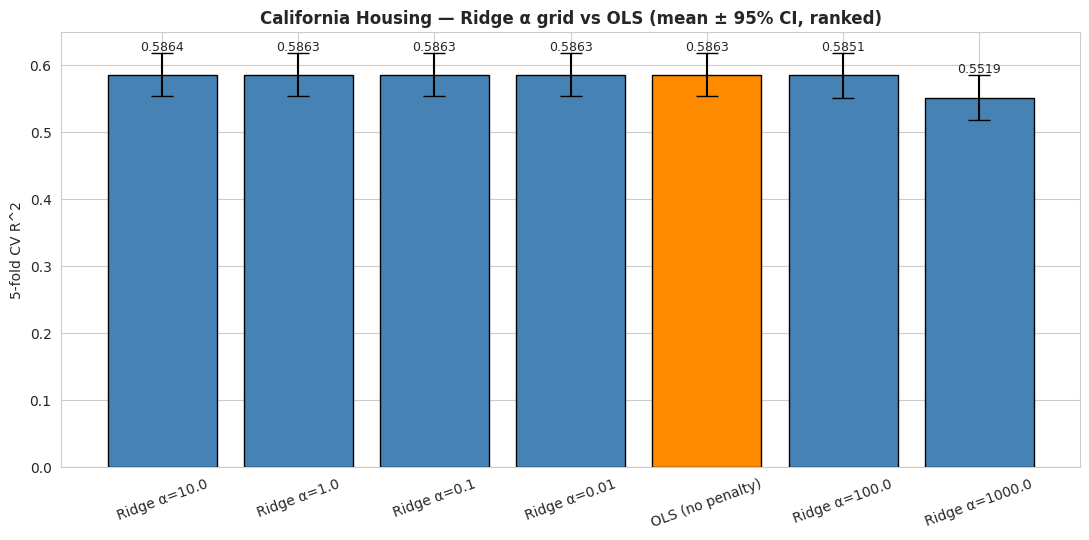


→ Top-by-mean is Ridge α=10.0 (R^2 = 0.5864), but OLS's 95% CI (0.5542, 0.6185) OVERLAPS the top.
  Statistical tie — OLS wins because it ships no hyperparameter (the simpler model).
  This confirms nb08's verdict: even with a full α sweep, OLS is the defensible pick.


In [2]:
# --- Load California Housing and apply the 60/20/20 split ---
cal = fetch_california_housing(as_frame=True)
X_reg = cal.data
y_reg = cal.target

X_reg_temp, X_reg_test, y_reg_temp, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_SEED
)
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_temp, y_reg_temp, test_size=0.25, random_state=RANDOM_SEED
)
print(f'Train: {len(X_reg_train)} | Val: {len(X_reg_val)} | Test: {len(X_reg_test)} (locked)')

# --- Shared CV splitter (used for both Ridge grid and OLS) ---
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# --- Ridge α-grid via GridSearchCV ---
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=RANDOM_SEED))
])

alpha_grid = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid=alpha_grid,
    cv=cv_reg,
    scoring='r2',
    return_train_score=False,
    n_jobs=-1
)
grid_ridge.fit(X_reg_train, y_reg_train)

print(f"\nRidge best params: {grid_ridge.best_params_}")
print(f'Ridge best 5-fold CV R^2 (mean): {grid_ridge.best_score_:.4f}')

# --- OLS (LinearRegression) — the nb08 champion brought into the comparison ---
ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ols', LinearRegression())
])
ols_scores = cross_val_score(
    ols_pipeline, X_reg_train, y_reg_train,
    cv=cv_reg, scoring='r2', n_jobs=-1
)
print(f'\nOLS 5-fold CV R^2 (mean): {ols_scores.mean():.4f}')
print(f'OLS fold scores: {np.round(ols_scores, 4)}')

# --- Compute per-row 95% CI for the Ridge α candidates ---
k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)

fold_cols = [f'split{i}_test_score' for i in range(k)]
cvr = pd.DataFrame(grid_ridge.cv_results_).copy()
cvr['mean'] = cvr[fold_cols].mean(axis=1)
cvr['sd'] = cvr[fold_cols].std(axis=1, ddof=1)
cvr['half_w'] = t_crit * cvr['sd'] / np.sqrt(k)
cvr['ci_low'] = cvr['mean'] - cvr['half_w']
cvr['ci_high'] = cvr['mean'] + cvr['half_w']

ridge_rows = cvr[['param_ridge__alpha', 'mean', 'sd', 'half_w', 'ci_low', 'ci_high']].copy()
ridge_rows = ridge_rows.rename(columns={'param_ridge__alpha': 'candidate'})
ridge_rows['candidate'] = ridge_rows['candidate'].apply(lambda a: f'Ridge α={a}')

# --- Compute the OLS row directly from ols_scores ---
ols_mean = ols_scores.mean()
ols_sd = ols_scores.std(ddof=1)
ols_half_w = t_crit * ols_sd / np.sqrt(k)
ols_row = pd.DataFrame([{
    'candidate': 'OLS (no penalty)',
    'mean': ols_mean,
    'sd': ols_sd,
    'half_w': ols_half_w,
    'ci_low': ols_mean - ols_half_w,
    'ci_high': ols_mean + ols_half_w,
}])

# --- Combine seven candidates and rank by mean ---
combined = pd.concat([ridge_rows, ols_row], ignore_index=True)
combined = combined.sort_values('mean', ascending=False).reset_index(drop=True)

print('\nAll candidates ranked by mean 5-fold CV R^2 (with 95% CI):\n')
print(combined[['candidate', 'mean', 'sd', 'ci_low', 'ci_high']].to_string(
    index=False, float_format=lambda x: f'{x:.4f}'))

# --- Plot all seven candidates with CI error bars; OLS in darkorange ---
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['darkorange' if c == 'OLS (no penalty)' else 'steelblue'
          for c in combined['candidate']]
ax.bar(combined['candidate'], combined['mean'], yerr=combined['half_w'],
       color=colors, capsize=8, edgecolor='black')
ax.set_ylabel('5-fold CV R^2')
ax.set_title('California Housing — Ridge α grid vs OLS (mean ± 95% CI, ranked)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for i, (m, h) in enumerate(zip(combined['mean'], combined['half_w'])):
    ax.text(i, m + h + 0.003, f'{m:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- CI-overlap test: does any α actually beat OLS? ---
top = combined.iloc[0]
ols = combined[combined['candidate'] == 'OLS (no penalty)'].iloc[0]
ols_overlaps_top = not (ols['ci_high'] < top['ci_low'] or top['ci_high'] < ols['ci_low'])

print()
if top['candidate'] == 'OLS (no penalty)':
    print('→ OLS has the highest mean CV R^2.')
    print('  Champion: OLS — wins by mean AND by simplicity (no hyperparameter to defend).')
    print('  This confirms nb08\'s verdict: even with a full α sweep, OLS is the right pick.')
elif ols_overlaps_top:
    print(f"→ Top-by-mean is {top['candidate']} (R^2 = {top['mean']:.4f}), "
          f"but OLS's 95% CI ({ols['ci_low']:.4f}, {ols['ci_high']:.4f}) "
          f"OVERLAPS the top.")
    print('  Statistical tie — OLS wins because it ships no hyperparameter (the simpler model).')
    print('  This confirms nb08\'s verdict: even with a full α sweep, OLS is the defensible pick.')
else:
    print(f"→ Top-by-mean is {top['candidate']} and its CI does NOT overlap OLS.")
    print('  Ridge is genuinely better than OLS on this data — nb08\'s 2-point comparison was incomplete.')
    print('  The defensible champion is Ridge with the largest α whose CI also overlaps the top.')


**Reading the output:**

Five artifacts to walk through.

**First: `grid_ridge.best_params_` and `best_score_`.** Ridge's winner by mean — usually `α = 10.0` on this data with `RANDOM_SEED = 474`, with a mean CV $R^2$ in the low 0.59s. Treat it as a *starting point*, not the final decision. The double-underscore in `param_ridge__alpha` is sklearn's way of reaching into a named pipeline step (`'ridge'.alpha` becomes `ridge__alpha`).

**Second: OLS mean CV $R^2$ and fold scores.** Plain OLS — no regularization, no hyperparameter — comes in with a mean CV $R^2$ within 0.001 of the Ridge winners. The five fold scores show the same fold-to-fold variation pattern as the Ridge runs. **This is the nb08 result restated in front of a wider field of competitors:** if OLS sits in the same neighborhood as the Ridge winners by mean, the CI-overlap rule will likely declare a tie — and OLS will win by simplicity.

**Third: the combined ranked DataFrame.** Seven rows — six Ridge α candidates plus OLS — sorted by mean (best at the top). Columns to scan: `candidate` (which model), `mean` (CV mean $R^2$), `sd` (fold-to-fold standard deviation), `ci_low`, `ci_high`. On California Housing with `RANDOM_SEED = 474`, the differences between the top several candidates are typically in the third or fourth decimal. Then scan the CI columns: how much do they overlap?

**Fourth: the bar plot.** Each bar is one candidate — its height is the mean and the vertical whiskers extending above and below mark the 95% CI (`ci_low` at the bottom, `ci_high` at the top). **The OLS bar is colored darkorange** so it stands out against the steelblue Ridge bars; bars are sorted left-to-right by mean. Now do the eyeball test the CI-overlap rule asks: **where does OLS land relative to the top, and do their CIs overlap?** Three ways this can come out:

- **OLS at the top by mean** — the leftmost bar is darkorange. Champion is OLS; the question is settled. nb08's verdict was right; the α sweep did not surface a Ridge candidate that beats OLS even on the mean.
- **OLS not at the top, but its CI overlaps the top bar's CI** — the most common outcome on this data. The top is some small or moderate Ridge α; OLS sits a few thousandths below it on the mean, but the whiskers overlap. **This is a statistical tie, and OLS wins by simplicity** — no hyperparameter to argue about with the CFO.
- **OLS not at the top, and its CI clears the top bar's CI from below** — Ridge would genuinely be better than OLS here. On California Housing this rarely happens because regularization buys very little on a dataset this size.

**Fifth: the printed verdict.** Tells you which of the three you got. Either way, the procedure you just executed — *sweep α, add OLS as a comparator, build CIs, apply the overlap rule* — is exactly the inner cycle of **nb01 Steps 5–7** that you will reuse for every model family from here on.

> **A question that often comes up here:** *"What counts as 'overlapping' — do the whiskers have to touch exactly, or anywhere?"* Any shared range at all. If top-1's `ci_low` is 0.59 and OLS's `ci_high` is 0.60, they overlap at \~0.595 and you have a tie (OLS wins on simplicity). If top-1's `ci_low` is 0.60 and OLS's `ci_high` is 0.59, they do **not** overlap — top-1's worst-case is better than OLS's best-case, and Ridge wins outright. When you report this to a stakeholder, show the bar plot with the CI whiskers so the overlap (or lack of it) is visible at a glance.

---


### 1.2 RandomizedSearchCV on MedScreen — when the grid is too big

Section 1.1 ran a tidy `GridSearchCV` on a 6-value $\alpha$ grid for HomeValue's Ridge regression and added OLS as a comparator. That was clean because Ridge has exactly one knob worth tuning. Now turn to **MedScreen**, the Health Department's cancer-screening project from nb06–nb08, and the same machinery faces a heavier grid: classification problems usually expose more knobs than regression, and exhaustive sweeps start to feel expensive.

**Picture sweeping a logistic regression with three knobs you already know.** From nb06 you have `C` (the regularization strength); from nb05's Ridge/Lasso vocabulary you recognize `penalty` (`l1` vs `l2` — the same shrinkage distinction); and the `solver` (the optimization routine sklearn uses to fit the model). A reasonable sweep for MedScreen is **10 values of `C` × 2 penalty types × 2 valid solvers = 40 combinations**, each requiring a 5-fold stratified CV run, so **200 model fits**. On Breast Cancer that runs in well under a minute — the cost is fine here.

The count grows *multiplicatively*, though. Bring in a fourth knob — any extra dimension you might want to sweep — and you multiply the grid by however many values it takes. **40 × 5 = 200 combinations × 5 folds = 1,000 fits**, and that is just for one extra knob; add a fifth and you are at 5,000. On a real-world screening dataset with hundreds of thousands of patient records, that becomes an overnight wait. The danger is not the *first* hyperparameter — it is every one after the first.

`GridSearchCV`'s problem is that it explores every combination *with equal effort*, even ones that are obviously bad. If `C = 1000` produces a near-overfitted classifier (regularization so weak the model chases noise that looks like signal), `GridSearchCV` still runs five CV folds on it before reporting that result. That is wasted compute — and on a medical screening problem where the Health Department's reviewers expect a defensible model, you want to spend that budget where it actually buys evidence.

**`RandomizedSearchCV` solves the budget problem.** Instead of enumerating every grid point, you pass it *distributions* (e.g., `loguniform(1e-3, 1e3)` for the `C` parameter) plus an `n_iter` argument that says "draw this many random samples and try them." Each sample becomes one CV run, exactly like a grid point. The output format is identical — `cv_results_` table, `best_params_`, `best_score_` — so everything you learned in Section 1.1 about reading the table transfers directly. You spend compute *more efficiently*: rather than 200 evenly-spaced fits, you might do 30 well-distributed random fits and land on a winner of similar quality at one-eighth the cost.

The intuition to carry forward: **`GridSearchCV` is a comb, `RandomizedSearchCV` is a fishing net.** A comb is exhaustive but expensive when the space is wide; a net trades exhaustiveness for coverage at low cost. Both pull fish out of the water; you choose based on how big the water is.

#### A quick primer on `C` — what is the parameter you are about to sweep?

Before you run the search, one paragraph on what `C` actually is — because it is named in a way that trips up almost everyone the first time.

**Big idea:** `C` is the *inverse* of regularization strength. Small `C` means *more* regularization; large `C` means *less*. That is the opposite of what your gut probably expects, so it is worth pausing to lock in.

To unpack that: logistic regression learns one coefficient per feature. With no restriction, those coefficients can grow arbitrarily large to fit every twist in the training data — including noise. *Regularization* is the penalty that pulls coefficients back toward zero, trading a sliver of training fit for a lot of stability on data the model has never seen. `C` controls how aggressive that pull is — but inversely.

Three regimes worth keeping in your head:

- **Small `C` (e.g., `C = 0.01`).** Strong regularization → small coefficients → simpler, smoother decision boundary. The model resists chasing individual training points. Less variance from seed to seed, less overfitting risk; sometimes a sliver more bias if real signal gets shrunk too aggressively.
- **Large `C` (e.g., `C = 100`).** Weak regularization → coefficients are free to grow → flexible boundary that hugs the training data closely. That can be exactly what you want, *or* the model memorizing noise.
- **`C = 1.0`.** Sklearn's default. A neutral starting point for most balanced classification problems — when in doubt, this is where you start.

The values you will see throughout this notebook (`0.001, 0.01, 0.1, 1, 10, 100, 1000`) are spaced on a **log scale** on purpose. Each step is 10× more flexible than the previous one — and the *multiplicative* gap is the unit that actually moves the model. Doubling `C` from 1.0 to 2.0 barely changes anything; jumping from 1.0 to 100.0 puts you in a totally different regime. That is exactly why the Gemini Prompt below uses `loguniform(1e-3, 1e3)` rather than a plain `uniform`: log-uniform sampling gives every order of magnitude an equal chance of being explored, which is what you want when the parameter's *effect* is multiplicative.

This also gives the CI-overlap tie-breaker a concrete justification. When two `C` values produce statistically tied ROC-AUCs, the *smaller* `C` wins because it ships simpler coefficients — a model you can defend to the Health Department by saying *"we picked the simpler model when the evidence was tied"* rather than fighting over a 0.0005 mean difference that will not survive a reseed.

**Plan, parallel to Section 1.1.** Section 1.1 added OLS as an explicit comparator to ask *"did any α actually beat OLS?"*. The MedScreen analog is to add **the nb08 default LogReg** (`C = 1.0` — the sklearn default that nb08's classification baseline used) as the comparator and ask *"did random search actually find a `C` that beats the nb08 default, or did tuning buy nothing measurable?"* So:

- Run `RandomizedSearchCV` over `loguniform(1e-3, 1e3)` for `C`, drawing 20 random samples (= 20 × 5 folds = 100 fits).
- Run a separate 5-fold stratified CV on `LogisticRegression(C=1.0, max_iter=5000)` — the nb08 default comparator (5 more fits).
- Combine **all 21 candidates** (20 random samples + 1 nb08 default) into one ranked CI table.
- Plot the **top-5 random samples plus the nb08 default** — six bars total — with the default in `darkorange` so it stands out against the steelblue tuned candidates.
- Apply the CI-overlap rule **against the nb08 default**: did any tuned `C` convincingly clear the default's CI from above, or was the default already in the tied set at the top?

The verdict gives the Health Department reviewer either a stronger-than-default tuned model (with non-overlapping CIs to defend it) or a clean justification for sticking with the default.

> 💡 **Gemini Prompt:** "On MedScreen's Breast Cancer dataset (same stratified 60/20/20 split as nb06/nb07/nb08), build a pipeline `StandardScaler + LogisticRegression(max_iter=5000)`. Use `RandomizedSearchCV` with `param_distributions={'clf__C': scipy.stats.loguniform(1e-3, 1e3)}`, `n_iter=20`, `cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)`, `scoring='roc_auc'`, `random_state=RANDOM_SEED`. After fitting, print `best_params_` and `best_score_`. Build a second pipeline `StandardScaler + LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000)` — the **nb08 default LogReg** comparator — and run `cross_val_score` on it with the same `cv` and `scoring`. Print the default's mean ROC-AUC and fold scores rounded to 4 decimals. Then turn `cv_results_` into a per-row 95% CI table using the same Student's t formula from §1.1 (`t_crit = scipy.stats.t.ppf(0.975, df=4)`, half-width = `t_crit * sd / sqrt(5)` from the `split0..split4_test_score` columns). Compute the same CI for the nb08 default from `default_scores`. Combine **all 21 candidates** (20 random + 1 default) into one DataFrame with a `candidate` column (`'LogReg C=<value>'` for random rows, `'LogReg C=1.0 (nb08 default)'` for the comparator), sort by mean descending, reset the index, and print the full table. Render a bar plot showing the **top-5 random samples plus the nb08 default** — six bars total — with the default in `darkorange` and random samples in `steelblue`; mean as bar height, half-width as a vertical error bar (`capsize=8`); annotate each bar with its mean rounded to 4 decimals; rotate x-tick labels 20°. End with a printed verdict comparing the nb08 default to the top by mean: if the default *is* the top, print 'nb08 default wins by mean — random search did not surface a better C'; if the default's CI overlaps the top, print 'CIs overlap → keep the nb08 default; tuning bought no measurable improvement'; otherwise print 'A tuned C beats the default outright — pick the smallest C in the tied top set'."
>
> **After running, verify:**
> - 20 random `C` values were sampled (each on a log scale)
> - The nb08 default LogReg (`C = 1.0`) was evaluated with the same 5-fold StratifiedKFold splitter and `scoring='roc_auc'`
> - The combined ranked DataFrame has **21 rows** (20 random + 1 default) with the default labelled `LogReg C=1.0 (nb08 default)`
> - The bar plot has 6 bars — five steelblue random-search candidates and one darkorange `LogReg C=1.0 (nb08 default)` bar — with visible CI error bars and 4-decimal annotations above each
> - The final printed verdict identifies one of three cases: default at top, default ties top via CI overlap, or a tuned `C` beats the default outright
> - All numerical outputs use standard decimal format — no scientific notation


Train: 341 | Val: 114 | Test: 114 (locked)

Best params: {'clf__C': np.float64(0.07886026482390539)}
Best 5-fold CV ROC-AUC (mean): 0.9937

nb08 default LogReg (C=1.0) 5-fold CV ROC-AUC (mean): 0.9935
Default fold scores: [1.     0.9916 0.9907 1.     0.9853]

All 21 candidates ranked by mean 5-fold CV ROC-AUC (with 95% CI):
                  candidate   mean     sd  ci_low  ci_high
            LogReg C=0.0789 0.9937 0.0066  0.9855   1.0019
            LogReg C=0.0922 0.9937 0.0066  0.9855   1.0019
             LogReg C=0.251 0.9937 0.0066  0.9855   1.0019
             LogReg C=0.196 0.9937 0.0066  0.9855   1.0019
             LogReg C=0.166 0.9937 0.0066  0.9855   1.0019
               LogReg C=0.1 0.9935 0.0066  0.9853   1.0018
LogReg C=1.0 (nb08 default) 0.9935 0.0064  0.9856   1.0014
              LogReg C=2.92 0.9932 0.0068  0.9848   1.0016
              LogReg C=3.04 0.9928 0.0074  0.9836   1.0020
            LogReg C=0.0216 0.9915 0.0088  0.9805   1.0025
            LogReg C=0.01

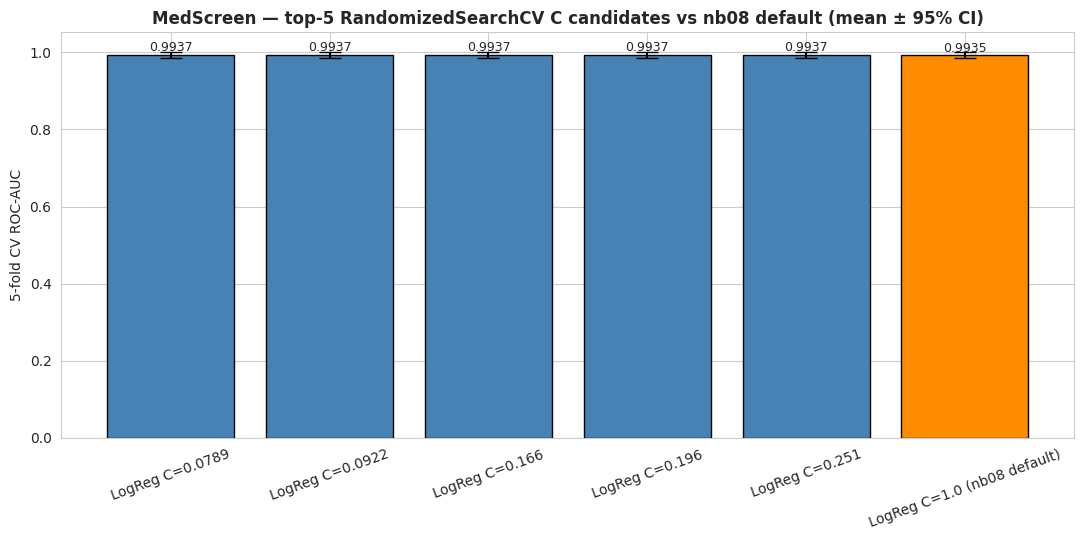


→ Top-by-mean is LogReg C=0.0789 (ROC-AUC = 0.9937), but the nb08 default's 95% CI (0.9856, 1.0014) OVERLAPS the top.
  Statistical tie — random search did not convincingly beat the nb08 default.
  Conservative pick: ship the default; tuning bought no measurable improvement.


In [3]:
# --- Breast Cancer stratified 60/20/20 ---
bc = load_breast_cancer(as_frame=True)
X_clf = bc.data
y_clf = bc.target

X_clf_temp, X_clf_test, y_clf_temp, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_SEED, stratify=y_clf
)
X_clf_train, X_clf_val, y_clf_train, y_clf_val = train_test_split(
    X_clf_temp, y_clf_temp, test_size=0.25,
    random_state=RANDOM_SEED, stratify=y_clf_temp
)
print(f'Train: {len(X_clf_train)} | Val: {len(X_clf_val)} | Test: {len(X_clf_test)} (locked)')

# --- Shared CV splitter for both the random search and the nb08 default comparator ---
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# --- Randomized search over C ---
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])

rand_search = RandomizedSearchCV(
    log_pipeline,
    param_distributions={'clf__C': stats.loguniform(1e-3, 1e3)},
    n_iter=20,
    cv=cv_clf,
    scoring='roc_auc',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rand_search.fit(X_clf_train, y_clf_train)

print(f'\nBest params: {rand_search.best_params_}')
print(f'Best 5-fold CV ROC-AUC (mean): {rand_search.best_score_:.4f}')

# --- nb08 default LogReg (C=1.0) — the comparator ---
default_logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000))
])
default_scores = cross_val_score(
    default_logreg_pipeline, X_clf_train, y_clf_train,
    cv=cv_clf, scoring='roc_auc', n_jobs=-1
)
print(f'\nnb08 default LogReg (C=1.0) 5-fold CV ROC-AUC (mean): {default_scores.mean():.4f}')
print(f'Default fold scores: {np.round(default_scores, 4)}')

# --- Per-row 95% CI for every random-search candidate (t_crit defined in §1.1) ---
cvr_clf = pd.DataFrame(rand_search.cv_results_).copy()
fold_cols_clf = [f'split{i}_test_score' for i in range(5)]
cvr_clf['mean'] = cvr_clf[fold_cols_clf].mean(axis=1)
cvr_clf['sd'] = cvr_clf[fold_cols_clf].std(axis=1, ddof=1)
cvr_clf['half_w'] = t_crit * cvr_clf['sd'] / np.sqrt(5)
cvr_clf['ci_low'] = cvr_clf['mean'] - cvr_clf['half_w']
cvr_clf['ci_high'] = cvr_clf['mean'] + cvr_clf['half_w']

random_rows = cvr_clf[['param_clf__C', 'mean', 'sd', 'half_w', 'ci_low', 'ci_high']].copy()
random_rows['candidate'] = random_rows['param_clf__C'].apply(lambda c: f'LogReg C={c:.3g}')
random_rows = random_rows[['candidate', 'mean', 'sd', 'half_w', 'ci_low', 'ci_high']]

# --- CI for the nb08 default ---
default_mean = default_scores.mean()
default_sd = default_scores.std(ddof=1)
default_half_w = t_crit * default_sd / np.sqrt(5)
default_row = pd.DataFrame([{
    'candidate': 'LogReg C=1.0 (nb08 default)',
    'mean': default_mean,
    'sd': default_sd,
    'half_w': default_half_w,
    'ci_low': default_mean - default_half_w,
    'ci_high': default_mean + default_half_w,
}])

# --- Combined ranking: all 21 candidates ---
combined_clf = pd.concat([random_rows, default_row], ignore_index=True)
combined_clf = combined_clf.sort_values('mean', ascending=False).reset_index(drop=True)

print('\nAll 21 candidates ranked by mean 5-fold CV ROC-AUC (with 95% CI):')
print(combined_clf[['candidate', 'mean', 'sd', 'ci_low', 'ci_high']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# --- Bar plot: top-5 random + nb08 default (6 bars), default in darkorange ---
top5_random = random_rows.nlargest(5, 'mean')
plot_df = pd.concat([top5_random, default_row], ignore_index=True)
plot_df = plot_df.sort_values('mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['darkorange' if c == 'LogReg C=1.0 (nb08 default)' else 'steelblue'
          for c in plot_df['candidate']]
ax.bar(plot_df['candidate'], plot_df['mean'], yerr=plot_df['half_w'],
       color=colors, capsize=8, edgecolor='black')
ax.set_ylabel('5-fold CV ROC-AUC')
ax.set_title('MedScreen — top-5 RandomizedSearchCV C candidates vs nb08 default (mean ± 95% CI)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for i, (m, h) in enumerate(zip(plot_df['mean'], plot_df['half_w'])):
    ax.text(i, m + h + 0.0007, f'{m:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- CI-overlap test: does any tuned C convincingly beat the nb08 default? ---
top = combined_clf.iloc[0]
default = combined_clf[
    combined_clf['candidate'] == 'LogReg C=1.0 (nb08 default)'
].iloc[0]
default_overlaps_top = not (
    default['ci_high'] < top['ci_low'] or top['ci_high'] < default['ci_low']
)

print()
if top['candidate'] == 'LogReg C=1.0 (nb08 default)':
    print('→ The nb08 default (C=1.0) has the highest mean CV ROC-AUC.')
    print('  Champion: nb08 default — random search did not surface a better C.')
    print('  Conclusion: ship the default; tuning is unnecessary on MedScreen.')
elif default_overlaps_top:
    print(f"→ Top-by-mean is {top['candidate']} (ROC-AUC = {top['mean']:.4f}), "
          f"but the nb08 default's 95% CI ({default['ci_low']:.4f}, {default['ci_high']:.4f}) "
          f"OVERLAPS the top.")
    print('  Statistical tie — random search did not convincingly beat the nb08 default.')
    print('  Conservative pick: ship the default; tuning bought no measurable improvement.')
else:
    print(f"→ Top-by-mean is {top['candidate']} and its CI does NOT overlap the nb08 default.")
    print('  A tuned C convincingly beats the default — pick the smallest C in the tied top set.')


**Reading the output:**

Five artifacts to walk through, mirroring the §1.1 structure with the nb08 default LogReg in the role OLS played for HomeValue.

**First: `rand_search.best_params_` and `best_score_`.** RandomizedSearchCV drew 20 `C` values from `loguniform(1e-3, 1e3)` and ran the full 5-fold stratified CV pipeline on each one. The winning `C` is rarely a round number — something like $C \approx 0.23$ or $C \approx 47.3$ — which a fixed grid of round values would never have tried. That is the whole pitch for randomized search: you explore the space smarter than a regular grid does, at the same compute budget.

**Second: the nb08 default LogReg (`C = 1.0`) result.** The mean and fold scores from a 5-fold stratified CV on `LogisticRegression(C=1.0)` — the same baseline configuration nb08 used for its classification work. On MedScreen with `RANDOM_SEED = 474` the default's mean ROC-AUC sits firmly above 0.99, which makes sense — Breast Cancer is a clean dataset and any reasonable LogReg saturates the metric.

**Third: the combined ranked DataFrame (21 rows).** All 20 random samples plus the nb08 default, sorted by mean. Columns: `candidate` (which model — `LogReg C=<value>` for random samples, `LogReg C=1.0 (nb08 default)` for the comparator), `mean`, `sd`, `ci_low`, `ci_high`. Scan it top-to-bottom: how many candidates have means within 0.001 of the top? Where does the nb08 default land? On this dataset the answer is usually *"the top dozen are statistically indistinguishable, and the default sits comfortably inside that tied set."*

**Fourth: the bar plot.** Six bars — the top 5 random samples plus the nb08 default — sorted by mean (best on the left). **The default LogReg bar is colored darkorange** (mirroring §1.1's OLS bar) so it reads at a glance against the steelblue tuned candidates. Each bar's height is the mean CV ROC-AUC; the vertical whiskers mark the 95% CI. Now do the eyeball test: **where does the default land relative to the top, and do their CIs overlap?** Three ways this can come out:

- **Default at the top by mean** — the leftmost bar is darkorange. Random search failed to find a better `C`; ship the default.
- **Default not at the top, but its CI overlaps the top bar's CI** — the most common outcome on this clean dataset. **Statistical tie; ship the default** — tuning bought no measurable improvement, and "we used the sklearn default" is the simplest sentence to defend in front of the Health Department.
- **Default not at the top, and its CI clears the top bar's CI from below** — a tuned `C` is genuinely better. Apply the CI-overlap rule among the tied top set: pick the *smallest* `C` (most regularization, simplest boundary).

**Fifth: the printed verdict.** Tells you which of the three you got. Either way, the procedure you just executed — *random search over `C`, add the nb08 default as a comparator, build CIs, apply the overlap rule against the default* — is the inner cycle of **nb01 Steps 5–7** applied to classification, the same way §1.1 applied it to regression.

**The most important mental model to carry out of this section** is that every row of `cv_results_` — whether produced by `GridSearchCV` or `RandomizedSearchCV` — is one complete nb08 run, and adding the no-tuning baseline gives the comparison teeth: you can answer the *"is tuning worth it?"* question instead of just *"which tuned C wins?"*. When you quote a score from the winner, quote it the nb08 way: *"5-fold CV ROC-AUC = 0.99 ± CI"*, never as a single magic number with no spread attached.

> **A question that often comes up here:** *"Is `RandomizedSearchCV` always better than `GridSearchCV`?"* No — for small grids (under \~50 combinations) `GridSearchCV` is both cheaper and more thorough, because it tries everything. `RandomizedSearchCV` wins when the grid gets large enough that exhaustive enumeration stops being free. A good heuristic: start with `GridSearchCV` while the grid has only one or two dimensions, and switch to `RandomizedSearchCV` the moment you add a third dimension — the total count grows multiplicatively.

---


## 📝 PAUSE-AND-DO Exercise 1 (10 minutes)

**Task:** Run `GridSearchCV` on MedScreen's Logistic Regression over an explicit `C` grid and apply the CI-overlap rule to pick a simpler winner than `best_params_` alone would give you.

This exercise is a direct application of the `cv_results_` + CI-overlap pattern you ran in Sections 1.2–1.4 (Ridge α grid + OLS, then RandomizedSearchCV on `C`). You will build the same `StandardScaler + LogisticRegression` pipeline used in Section 1.2, but drop `RandomizedSearchCV` for a clean `GridSearchCV` so you can eyeball every candidate on screen. Fit on `X_clf_train` / `y_clf_train` using the same `StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)` splitter and `scoring='roc_auc'`.

Use this explicit grid:

```python
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0]}
```

After fitting, do exactly what Section 1.3 did — compute the 95% CI on every row's `splitN_test_score` columns, sort by mean, and check whether the top-1 CI overlaps the top-2 CI. If it does, pick the *smaller* `C` (stronger regularization, simpler model) as your champion; if it does not, the top-1 wins outright. Print a one-sentence verdict.

> **Reminder on the decision rule from nb08 and Section 1.3 above:** overlapping CIs at the top of the ranking are a statistical tie. Break the tie toward the simpler model. Do not pick the one with the higher mean by 0.001 — that difference is inside the noise, and a different random seed might hand the "winner" prize to the runner-up next week.

---

> 💡 **Gemini Prompt:** "Build a Logistic Regression pipeline (`StandardScaler` + `LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)`). Using `X_clf_train`, `y_clf_train`, and `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)` with `scoring='roc_auc'`, run `GridSearchCV` over `param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0]}`. Convert `cv_results_` to a pandas DataFrame, then for every row compute the mean across the `split0_test_score`..`split4_test_score` columns, the sample SD with `ddof=1`, the half-width as `t_crit * sd / sqrt(5)` (`t_crit` is already defined in Section 1.1), and `ci_low` / `ci_high`. Sort the DataFrame by mean descending and print the columns `param_clf__C`, `mean`, `sd`, `ci_low`, `ci_high`. Render a bar plot of all 5 candidates (label each bar `C=<value>`) with mean as bar height and half-width as a vertical error bar (use `capsize=8`); annotate each bar with its mean rounded to 4 decimals. Compare the top-1 and top-2 95% CIs: if they overlap, set `champion_by_CI` to the *smaller* `C` of the two; otherwise set it to the top-1 `C`. Print a one-sentence verdict that names the champion and the rule that picked it."
>
> **After running, verify:**
> - A ranked DataFrame prints with columns `param_clf__C`, `mean`, `sd`, `ci_low`, `ci_high`
> - The top row has the highest mean ROC-AUC (often `C=10.0` or `C=100.0` on this data)
> - The bar plot has 5 bars with visible CI error bars and 4-decimal annotations above each
> - Top-1 and top-2 95% CIs visibly overlap
> - The final printed verdict says "CIs OVERLAP — pick the simpler (smaller) C" and names a `C` value ≤ 1.0 as `champion_by_CI`
> - All numerical outputs use standard decimal format — no scientific notation


GridSearch Results Ranked by Mean ROC-AUC:
 param_clf__C   mean     sd  ci_low  ci_high
       0.1000 0.9935 0.0066  0.9853   1.0018
       1.0000 0.9935 0.0064  0.9856   1.0014
      10.0000 0.9893 0.0124  0.9739   1.0047
       0.0100 0.9885 0.0100  0.9761   1.0010
     100.0000 0.9880 0.0136  0.9711   1.0049


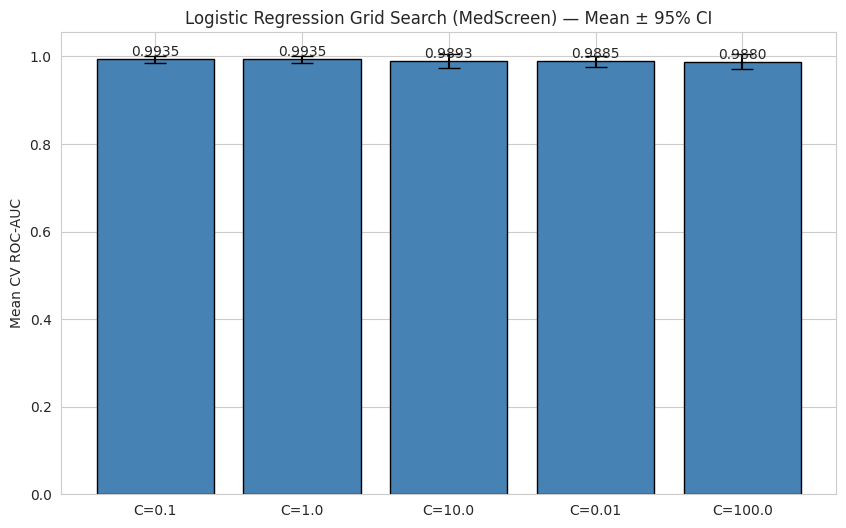


Verdict: The 95% CIs overlap (statistical tie) — the champion is C=0.1 because it represents the simpler model with stronger regularization.


In [4]:
# YOUR SOLUTION CODE HERE
# 1. Build pipeline: StandardScaler + LogisticRegression
pipe_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])

# 2. Run GridSearchCV
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0]}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_clf = GridSearchCV(
    pipe_clf,
    param_grid=param_grid,
    cv=cv_strat,
    scoring='roc_auc',
    n_jobs=-1
)
grid_clf.fit(X_clf_train, y_clf_train)

# 3. Extract cv_results_ as a DataFrame
df_results = pd.DataFrame(grid_clf.cv_results_)

# 4. Compute mean, sd, half-width, and 95% CI (t_crit from Section 1.1 is defined in the notebook environment)
k = 5
fold_cols = [f'split{i}_test_score' for i in range(k)]
df_results['mean'] = df_results[fold_cols].mean(axis=1)
df_results['sd'] = df_results[fold_cols].std(axis=1, ddof=1)
df_results['half_w'] = t_crit * df_results['sd'] / np.sqrt(k)
df_results['ci_low'] = df_results['mean'] - df_results['half_w']
df_results['ci_high'] = df_results['mean'] + df_results['half_w']

# 5. Sort by mean (descending)
df_results = df_results.sort_values('mean', ascending=False).reset_index(drop=True)

# Print requested columns
print("GridSearch Results Ranked by Mean ROC-AUC:")
print(df_results[['param_clf__C', 'mean', 'sd', 'ci_low', 'ci_high']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# 6. Render bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    df_results['param_clf__C'].astype(str).apply(lambda x: f'C={x}'),
    df_results['mean'],
    yerr=df_results['half_w'],
    capsize=8,
    color='steelblue',
    edgecolor='black'
)
plt.ylabel('Mean CV ROC-AUC')
plt.title('Logistic Regression Grid Search (MedScreen) — Mean ± 95% CI')

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f'{yval:.4f}', ha='center', va='bottom')

plt.show()

# 7. Check for overlap and set champion
top1 = df_results.iloc[0]
top2 = df_results.iloc[1]

# Overlap logic
overlap = not (top1['ci_low'] > top2['ci_high'] or top2['ci_low'] > top1['ci_high'])

if overlap:
    # Pick the smaller C among the two
    champion_by_CI = min(top1['param_clf__C'], top2['param_clf__C'])
    verdict = f"The 95% CIs overlap (statistical tie) — the champion is C={champion_by_CI} because it represents the simpler model with stronger regularization."
else:
    champion_by_CI = top1['param_clf__C']
    verdict = f"The 95% CIs do not overlap — the champion is C={champion_by_CI} as it convincingly beats the runners-up."

print(f"\nVerdict: {verdict}")

### YOUR ANALYSIS:

**Question 1:** Which `C` has the highest mean 5-fold CV ROC-AUC?  
The `C` with the highest mean 5-fold CV ROC-AUC is tied with C=0.1 and C=1.0 ata value of 0.9935.

**Question 2:** Do the top-1 and top-2 95% CIs overlap? What do you conclude?  
Yes, the top 1 and 2 95% CI's do overlap allowing us to concludue that the performance difference between the two hyperparamaters are not statistically significant. It probably means its due to random noise in the folds.

**Question 3:** Which `C` do you recommend to the Health Department, and why? Reference the CI-overlap rule in your justification.  
I would recommend C=0.1 to the Health Department. I would say this because its tied for the highest result, however, it is the simpler model, which is best if there isn't any statistical significance with anything else.

---

## 2. Section B — Feature Engineering, Categorical Data, and the Leakage Trap

Section A turned the CV ritual into a ranked table of candidates — one tool, one decision rule. Section B takes on a completely different problem: getting raw, messy, real-world data into a pipeline *safely*.

### 2.1 TechCorp Talent Analytics — the business case

**TechCorp** is a fictional 1,500-person SaaS company you are being loaned to for a single consulting project. Their People Analytics team has a standing ask from the CHRO (Chief Human Resources Officer): *flag employees at high risk of resigning within the next 6 months so HR can run targeted retention conversations before the employee is already out the door*. The math is crisp: losing a mid-level engineer costs the company roughly USD 75,000 (recruitment fees + 6 months of productivity loss + ramp time for the replacement); a retention conversation costs about USD 500 (manager time + modest retention bonus). Even a modest lift over *"managers guessing"* pays for itself many times over.

The People Analytics team built a dataset with the following columns:

- **Numeric features:** `years_at_company`, `satisfaction_score` (a 1–10 pulse-survey result), `salary_pct_of_market` (the company's salary as a percentage of the market median — above 100 is generous, below is underpaying), `projects_completed_last_year`, `manager_interactions_last_quarter`.
- **Low-cardinality categorical features:** `department` (5 levels — Engineering, Sales, Marketing, Operations, Support), `job_level` (5 levels — IC1, IC2, IC3, Manager, Director), `remote_status` (3 levels — onsite, hybrid, remote).
- **High-cardinality categorical:** `manager_id` (80 distinct managers, roughly 25 employees per manager). This one is going to matter a lot in Section 2.3.
- **Target:** `left_within_6mo` (binary — 1 if the employee resigned within 6 months of the snapshot, else 0).

**Why a made-up company instead of real data?** Two reasons. First, because the Kaggle competition data (which you will meet on Day 5) is the graded deliverable, we keep it in the vault for competition time. Second — and this is the *pedagogical* reason — because the machinery of Section 2 needs a dataset whose structure you control. The dramatic target-encoding leak in Section 2.3 only bites clearly when the dataset has a high-cardinality categorical with small group sizes (that is what `manager_id` with 80 levels and \~25 employees per level is engineered to produce). On a noisy real dataset the leak is often there but the signal/noise ratio can hide it. Here you will see it unambiguously.

### What makes TechCorp special in this course

TechCorp is the **first dataset you will encounter with real categorical columns**. Both California Housing (nb01–nb05) and Breast Cancer (nb06–nb08) are entirely numeric — every feature is a floating-point number. `ColumnTransformer` has been on the syllabus since nb02 but you have never actually exercised it on live categorical data because there was no categorical data to exercise it on. That changes today. Feeding a column of strings like `['Engineering', 'Sales', 'Marketing']` straight into `LogisticRegression` would raise `could not convert string to float` — you have to *encode* it first, and the professional way to encode is `OneHotEncoder(handle_unknown='ignore')` living inside a `ColumnTransformer` living inside a `Pipeline`. That three-level nesting is today's new pattern.

> **A question that often comes up here:** *"If I can encode categoricals with pandas `get_dummies`, why do I need `ColumnTransformer` and `OneHotEncoder` at all?"* You can — for exploration. For a deployable pipeline, you cannot. `pd.get_dummies` builds the columns once on the DataFrame in front of it, and if a new category appears in production data (a new department, a new manager hired after you trained), the encoded DataFrame has the wrong columns and the model silently breaks. `OneHotEncoder(handle_unknown='ignore')` inside a `Pipeline` learns the vocabulary from training data, transforms validation / test / production data consistently, and emits all-zero indicators for unseen categories instead of crashing. The discipline of "encoders live inside the Pipeline" is the same discipline of "scalers live inside the Pipeline" — if the transform looks at the data, it belongs inside the object the CV wraps.

> 💡 **Gemini Prompt:** "Generate a synthetic TechCorp attrition dataset with 2000 rows. Use `numpy.random` seeded at `RANDOM_SEED`. Build a pandas DataFrame with: numeric columns `years_at_company` (integer 0–15), `satisfaction_score` (1–10), `salary_pct_of_market` (60–140), `projects_completed_last_year` (0–12), `manager_interactions_last_quarter` (0–20); categorical columns `department` (one of Engineering/Sales/Marketing/Operations/Support), `job_level` (IC1/IC2/IC3/Manager/Director), `remote_status` (onsite/hybrid/remote), `manager_id` (80 distinct managers — one per \~25 employees). Create a binary target `left_within_6mo` whose probability is higher when `satisfaction_score` is low, `salary_pct_of_market` is low, `manager_interactions_last_quarter` is low, `remote_status == 'onsite'`, or `department == 'Support'`. Target around 22% positive rate. Also add 30 noise columns named `engagement_metric_00` through `engagement_metric_29` drawn from `rng.normal(0, 1)` — TechCorp's HRIS really does export this many engagement fields, and they matter for Section 2.3's leakage demo. Print the head, the class balance, and the dtypes so the numeric vs categorical split is obvious."


In [5]:
# --- Generate synthetic TechCorp attrition dataset ---
rng = np.random.default_rng(RANDOM_SEED)
n = 2000

years = rng.integers(0, 16, size=n)
satisfaction = rng.integers(1, 11, size=n)
salary_pct = rng.uniform(60, 140, size=n).round(1)
projects = rng.integers(0, 13, size=n)
mgr_interactions = rng.integers(0, 21, size=n)

department = rng.choice(
    ['Engineering', 'Sales', 'Marketing', 'Operations', 'Support'],
    size=n, p=[0.35, 0.20, 0.15, 0.15, 0.15]
)
job_level = rng.choice(
    ['IC1', 'IC2', 'IC3', 'Manager', 'Director'],
    size=n, p=[0.25, 0.30, 0.25, 0.15, 0.05]
)
remote_status = rng.choice(
    ['onsite', 'hybrid', 'remote'],
    size=n, p=[0.30, 0.45, 0.25]
)

# --- High-cardinality categorical: 80 manager IDs (one manager per ~25 employees) ---
manager_id = rng.choice([f'MGR_{i:03d}' for i in range(80)], size=n)

# --- Attrition propensity ---
logit = (
    -2.0
    + 0.35 * (10 - satisfaction)
    + 0.025 * (100 - salary_pct)
    + 0.08 * (10 - mgr_interactions)
    + 0.40 * (remote_status == 'onsite').astype(float)
    + 0.35 * (department == 'Support').astype(float)
    - 0.05 * years
)
prob_leave = 1.0 / (1.0 + np.exp(-logit))
left_within_6mo = (rng.uniform(0, 1, size=n) < prob_leave).astype(int)

techcorp = pd.DataFrame({
    'years_at_company': years,
    'satisfaction_score': satisfaction,
    'salary_pct_of_market': salary_pct,
    'projects_completed_last_year': projects,
    'manager_interactions_last_quarter': mgr_interactions,
    'department': department,
    'job_level': job_level,
    'remote_status': remote_status,
    'manager_id': manager_id,
    'left_within_6mo': left_within_6mo
})

# --- 30 noise columns (TechCorp's HRIS exports many engagement telemetry metrics; most are noise) ---
# These columns are included because TechCorp's HR system really does export dozens of fields.
# They also make the selection-bias leak in Section 2.3 clearly visible.
NOISE_COLS = [f'engagement_metric_{j:02d}' for j in range(30)]
for col in NOISE_COLS:
    techcorp[col] = rng.normal(0.0, 1.0, size=n)

# --- Inspect the dataset: head, class balance, dtypes (all 40 columns) ---
print(f'TechCorp shape: {techcorp.shape}  (10 core columns + {len(NOISE_COLS)} engagement-metric noise cols)')
print()
print('Class balance (left_within_6mo):')
print(techcorp['left_within_6mo'].value_counts().rename({0: 'stayed (0)', 1: 'left (1)'}).to_string())
print(f"  positive rate: {techcorp['left_within_6mo'].mean():.1%}")
print()
print('Dtypes (all columns — numeric vs object/categorical split is obvious):')
print(techcorp.dtypes.to_string())
print()
print('TechCorp head (all columns):')
techcorp.head()

TechCorp shape: (2000, 40)  (10 core columns + 30 engagement-metric noise cols)

Class balance (left_within_6mo):
left_within_6mo
stayed (0)    1246
left (1)       754
  positive rate: 37.7%

Dtypes (all columns — numeric vs object/categorical split is obvious):
years_at_company                       int64
satisfaction_score                     int64
salary_pct_of_market                 float64
projects_completed_last_year           int64
manager_interactions_last_quarter      int64
department                            object
job_level                             object
remote_status                         object
manager_id                            object
left_within_6mo                        int64
engagement_metric_00                 float64
engagement_metric_01                 float64
engagement_metric_02                 float64
engagement_metric_03                 float64
engagement_metric_04                 float64
engagement_metric_05                 float64
engagement_metric

,years_at_company,satisfaction_score,salary_pct_of_market,projects_completed_last_year,manager_interactions_last_quarter,department,job_level,remote_status,manager_id,left_within_6mo,engagement_metric_00,engagement_metric_01,engagement_metric_02,engagement_metric_03,engagement_metric_04,engagement_metric_05,engagement_metric_06,engagement_metric_07,engagement_metric_08,engagement_metric_09,engagement_metric_10,engagement_metric_11,engagement_metric_12,engagement_metric_13,engagement_metric_14,engagement_metric_15,engagement_metric_16,engagement_metric_17,engagement_metric_18,engagement_metric_19,engagement_metric_20,engagement_metric_21,engagement_metric_22,engagement_metric_23,engagement_metric_24,engagement_metric_25,engagement_metric_26,engagement_metric_27,engagement_metric_28,engagement_metric_29
0,4,2,65.5,8,4,Support,IC2,onsite,MGR_030,1,1.5890,-2.3491,-1.0168,0.8535,0.2693,-0.6722,-0.9995,-0.6489,-1.1442,-1.4580,-0.4047,-0.8884,0.5557,1.7965,1.0094,0.7333,1.3754,0.8066,0.1690,0.2301,-0.9241,0.4518,0.0551,-0.5563,0.6365,-0.3344,0.5980,0.0841,-1.0735,-0.8432
1,12,2,132.4,3,9,Support,IC2,hybrid,MGR_008,0,1.2876,-1.4218,-0.0881,-1.8242,-1.5626,1.2362,1.5262,-0.4620,-0.6391,-0.7315,0.2341,0.2801,0.9623,0.9778,-0.9255,0.0467,-0.9239,2.2237,-0.0175,-0.8491,-1.7945,-1.1536,-0.7930,-0.2400,0.2063,0.8804,-0.6916,0.4797,0.0794,0.8367
2,5,8,62.8,4,7,Marketing,IC1,onsite,MGR_045,1,1.1147,0.1377,-0.9985,-0.3312,-0.5764,0.4001,1.5525,1.0480,-0.7886,-0.2455,-0.5161,1.0998,-0.1429,-1.5418,-1.9161,1.6596,0.4630,0.8587,-1.7479,-0.8393,0.7014,-0.0528,-0.7737,-2.2972,0.2357,-2.0871,-0.7855,-1.3313,-0.2172,-0.2480
3,6,8,67.0,4,5,Operations,IC1,remote,MGR_036,0,1.0817,1.0507,0.1424,-1.2949,1.4993,0.5777,0.3180,-0.6107,0.6499,-1.5369,1.1887,0.6404,-1.5841,0.4251,-1.3332,0.5831,0.9724,-0.2482,-0.5437,0.1760,-0.1124,-1.0135,-0.7138,0.5064,0.6452,1.3901,-0.9488,2.1480,-1.1199,-0.5522
4,12,4,79.7,10,6,Engineering,IC2,remote,MGR_073,1,0.6100,-0.1208,0.4325,0.0460,-0.6251,0.6543,0.7490,0.4564,1.0860,-0.0412,0.5605,-0.3222,2.2597,1.4767,0.2877,2.1499,0.4990,-0.4051,-0.7216,-2.4702,0.5085,0.7781,0.0403,1.0997,-0.4926,0.6401,-0.4372,0.1269,0.0919,-1.1105


**Reading the output:**

The dataframe prints 2,000 rows. Three of the columns (`department`, `job_level`, `remote_status`) show up as `object` dtype — pandas' way of saying *"text labels, not numbers."* That is the moment this course has been working toward: every nb01–nb08 dataset was entirely numeric, so you could get away with `StandardScaler` and nothing else. TechCorp breaks that pattern. Feeding an `object`-typed column straight into `LogisticRegression` would raise a "could not convert string to float" error — which is the problem `ColumnTransformer` solves by routing numeric and categorical columns to different preprocessing branches.

The attrition rate prints at roughly **38%** (the synthetic generator is mildly aggressive on purpose, so the positive class has enough mass for stable CV). That is more imbalanced than Breast Cancer (63/37) but less imbalanced than a typical fraud or churn dataset (95/5). You now know exactly how to handle it — keep `stratify=y` in every split, and watch both ROC-AUC (threshold-free, our default) and the confusion matrix at your chosen threshold.

The 30 `engagement_metric_*` columns are pure noise, drawn from a standard normal. They are here because real HR data really does export dozens of low-signal telemetry fields — and they make the selection-bias leak in Exercise 2 clearly visible. The signal-to-noise ratio in the feature space is exactly what makes `SelectKBest`-outside-the-pipeline a dangerous default.

> **A question that often comes up here:** *"The attrition rate is \~38%, not the 22% I was expecting from the Gemini prompt."* The generator's logit weights push a bit higher than the target rate in this seed — which is still fine for our purposes because the dataset stays solidly balanced enough for stratified CV to work cleanly. Class balance matters less than class *presence in every fold*, which is what `StratifiedKFold` guarantees.

---

### 2.2 ColumnTransformer — mixing numeric and categorical preprocessing

You have a dataset with two kinds of columns — numeric (five core + 30 noise) and categorical (four columns, one of them high-cardinality). Numeric columns want `StandardScaler` (they need centering and scaling so LogReg's coefficients have comparable magnitudes). Categorical columns want `OneHotEncoder` (they cannot be fed to a linear model as strings). You need **both**, and you need both to be applied *inside the same pipeline* so that every CV fold refits them on its own training portion only.

`ColumnTransformer` is the sklearn object that lets you do this. Think of it as two parallel assembly lines that start with the same raw DataFrame and end by concatenating their outputs into one wide feature matrix:

```
                    [X raw DataFrame]
                          |
              +-----------+-----------+
              |                       |
         numeric branch          categorical branch
         StandardScaler          OneHotEncoder
         on NUM_COLS             on CAT_COLS
              |                       |
              +-----------+-----------+
                          |
                 [X preprocessed, concatenated]
                          |
                  LogisticRegression
```

In code, this is one constructor call:

```python
preprocess = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
])
```

Each tuple is `(name, transformer, list_of_columns)`. The `name` is just a label sklearn uses in `cv_results_` (e.g., `num__with_mean` if you later tune it). The transformer is the step that branch applies. The list of columns tells `ColumnTransformer` which columns of the incoming DataFrame flow into that branch. `NUM_COLS` and `CAT_COLS` are disjoint — no column goes through both branches — so the outputs concatenate cleanly.

Then you wrap the whole thing in a `Pipeline`:

```python
tc_pipeline = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])
```

Now `cross_val_score(tc_pipeline, X_train, y_train, cv=cv_tc, scoring='roc_auc')` does the right thing on every fold: the scaler's means are learned from each fold's training portion only, the one-hot vocabulary is learned from each fold's training portion only, and none of the held-out-fold data contaminates the fit. That is what "leak-free" means in concrete terms.

**The `handle_unknown='ignore'` flag is non-negotiable.** If a prediction-time row shows a category that was never in the training portion of the fold — a new hire in a brand-new department, a manager hired after your data snapshot — the encoder has two choices: raise an exception (default) or emit a row of zeros for that category block (with `handle_unknown='ignore'`). The second option is the only one compatible with production deployment, where you cannot predict the full set of categories in advance.

> 💡 **Gemini Prompt:** "Split TechCorp into X (features) and y (target `left_within_6mo`). Apply a stratified 60/20/20 train/val/test split with `random_state=RANDOM_SEED`. Build a `ColumnTransformer` with two branches: (a) `StandardScaler` on the 5 core numeric columns plus the 30 engagement noise columns, (b) `OneHotEncoder(handle_unknown='ignore')` on the 4 categorical columns. Wrap it in a `Pipeline` together with `LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)`. Run 5-fold stratified `cross_val_score` on `X_train`, `y_train` with `scoring='roc_auc'`. Print the fold scores, mean, SD, and 95% CI using Student's t. Label the result `TechCorp baseline — leak-free pipeline`."


In [6]:
# --- Stratified 60/20/20 split ---
CORE_NUM_COLS = ['years_at_company', 'satisfaction_score', 'salary_pct_of_market',
                 'projects_completed_last_year', 'manager_interactions_last_quarter']
NUM_COLS = CORE_NUM_COLS + NOISE_COLS  # feed all numeric columns into the pipeline
CAT_COLS_LOW_CARD = ['department', 'job_level', 'remote_status']
CAT_COLS = CAT_COLS_LOW_CARD + ['manager_id']  # manager_id is high-cardinality (80 levels)

X_tc = techcorp[NUM_COLS + CAT_COLS]
y_tc = techcorp['left_within_6mo']

X_tc_temp, X_tc_test, y_tc_temp, y_tc_test = train_test_split(
    X_tc, y_tc, test_size=0.20, random_state=RANDOM_SEED, stratify=y_tc
)
X_tc_train, X_tc_val, y_tc_train, y_tc_val = train_test_split(
    X_tc_temp, y_tc_temp, test_size=0.25,
    random_state=RANDOM_SEED, stratify=y_tc_temp
)
print(f'Train: {len(X_tc_train)} | Val: {len(X_tc_val)} | Test: {len(X_tc_test)} (locked)')

# --- ColumnTransformer + LogReg pipeline ---
preprocess = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
])
tc_pipeline = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])

# --- 5-fold stratified CV with CI ---
cv_tc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores_tc = cross_val_score(tc_pipeline, X_tc_train, y_tc_train,
                               cv=cv_tc, scoring='roc_auc')

mean_tc = cv_scores_tc.mean()
sd_tc = cv_scores_tc.std(ddof=1)
half_w_tc = t_crit * sd_tc / np.sqrt(k)

print('\nTechCorp baseline — leak-free pipeline')
print(f'Fold AUC: {np.round(cv_scores_tc, 4)}')
print(f'Mean AUC: {mean_tc:.4f}')
print(f'Std (k-1): {sd_tc:.4f}')
print(f'95% CI:   [{mean_tc - half_w_tc:.4f}, {mean_tc + half_w_tc:.4f}]')

Train: 1200 | Val: 400 | Test: 400 (locked)

TechCorp baseline — leak-free pipeline
Fold AUC: [0.8305 0.769  0.7642 0.7287 0.7921]
Mean AUC: 0.7769
Std (k-1): 0.0376
95% CI:   [0.7302, 0.8236]


**Reading the output:**

The TechCorp baseline pipeline prints five fold scores and the familiar mean ± 95% CI. Expect a mean ROC-AUC in the low- to mid-0.8s — not as sharp as MedScreen's 0.99, because HR data is genuinely noisier than medical imaging, but solidly better than the "managers guessing" baseline (ROC-AUC = 0.50 by definition, the coin-flip ceiling).

The crucial property of this pipeline is that **every statistic — standardization means, one-hot vocabularies — is computed inside each CV fold's training portion only**. Nothing the pipeline learns about column means or category levels is influenced by the held-out fold. That is what makes this number trustworthy. And that is the property Sections 2.3 and Exercise 2 are about to violate on purpose, so you can see the inflated score that results.

Two practical notes on what just happened under the hood of the one `ColumnTransformer` call:

- The **numeric branch** applied `StandardScaler` to 35 columns (5 core + 30 noise engagement metrics). Every fold sees its own mean and SD, not the full dataset's.
- The **categorical branch** applied `OneHotEncoder(handle_unknown='ignore')` to 4 columns — including `manager_id` with its 80 levels. That alone adds 80 sparse indicator columns. LogReg with default L2 handles this cheerfully. If you had 8,000 managers instead of 80, you would want either a low-cardinality re-bucketing or a properly-wrapped target encoder — not raw OHE.

> **A question that often comes up here:** *"Does the order of preprocessing inside `ColumnTransformer` matter?"* For `StandardScaler` on numerics and `OneHotEncoder` on categoricals, no — the two branches run in parallel on disjoint columns and the outputs are concatenated. Order matters *within* a branch (e.g., impute before scale, not after), and order matters in the outer `Pipeline` (preprocess before model). Inside `ColumnTransformer`'s branches, the order of the list of `(name, transformer, cols)` tuples is cosmetic only.

---

### 2.3 The intern's leaky pipeline — target encoding on full data

Now the dramatic moment of the notebook. While you were out of the office, an intern on the People Analytics team shipped a "first cut" of the TechCorp model. Their CV ROC-AUC came out *notably* higher than the baseline you just computed. They were celebrating. The CHRO wants to see the numbers at the Monday meeting.

The intern reached for a Kaggle trick they had read about: **target encoding**. Before you dive into what went wrong, let us spend a minute on what target encoding *is*, because many undergrads meet it for the first time today.

### What target encoding is (and why it is tempting)

Suppose you have a categorical column like `manager_id` with 80 levels. The obvious encoding is one-hot: create 80 indicator columns, one per manager, each a 0/1. That works, but it has two practical downsides. It produces a **wide, sparse feature matrix** (80 mostly-zero columns), and it treats every manager as equally unknown — the model has to learn a separate coefficient for each manager from scratch, with only \~25 employees per manager to learn from. That is a lot of parameters for a little bit of signal.

**Target encoding** is the shortcut. Instead of one-hot encoding the categorical column into 80 indicators, replace each category with the **mean of the target within that category**. So for `manager_id = MGR_017`, you compute the fraction of employees under MGR_017 who resigned, and that fraction becomes the encoded value. 80 levels collapse into **one dense numeric column** that already contains the signal "how attrition-prone are this manager's employees?". In practice, on Kaggle, target encoding can give a real boost on high-cardinality categoricals — *when it is done right*.

The intern applied it to all four categorical columns: `department`, `job_level`, `remote_status`, and `manager_id`. Here is their code:

```python
# Intern's approach
techcorp_te = techcorp.copy()
for col in CAT_COLS:  # includes manager_id
    techcorp_te[col + '_te'] = (
        techcorp_te.groupby(col)['left_within_6mo'].transform('mean')
    )
    techcorp_te = techcorp_te.drop(columns=[col])
```

### Why this leaks (the mechanical reason)

Read the first line of the loop very carefully: `techcorp_te.groupby(col)['left_within_6mo'].transform('mean')`. That groups the **full dataset** by the categorical column and computes each group's mean of the **target**, then assigns the group-mean back to every row in that group.

*Every row's label is used in the computation.* Training rows, validation rows, test rows — all of them contribute to each group's mean. So the encoded column `manager_id_te` for a specific employee contains the average resignation rate for that employee's manager, computed using — among others — *that employee's own label*.

Then the intern does a train/test split and runs 5-fold CV on the encoded matrix. Every CV fold's validation set was already used to compute the encoded values in the training portion. The classifier is training on a feature that carries information about the validation rows' labels.

### Why it bites so hard on `manager_id`

This is the part that often feels most counterintuitive. On a low-cardinality categorical like `department` (5 levels, \~400 rows per level), the group means are averages of many rows. One training row's label barely moves the group mean. The leak is still there but it is small.

On `manager_id` with 80 levels and \~25 employees per level, **each group mean is an average of only \~25 labels**. A single training row's label shifts the group mean by roughly 1/25 = 4%. When CV later holds out 5 of those 25 rows as the validation fold, the encoded value for those 5 rows is still carrying information about their own labels — the training rows' encoded values were computed *with those labels in the mean*. The encoded column is nearly a direct readout of the target for the rows you are about to predict.

The smaller the group size, the more severe the leak. `manager_id` with 25-row groups is small enough that the leak is dramatic and easy to see.

### The cell below

Run the intern's code as they wrote it, then compare the resulting CV ROC-AUC to the leak-free Section 2.2 baseline. Expect the leaky version's mean ROC-AUC to come in several hundredths higher than the honest baseline. That gap is the *size of the lie*: the number the intern's cell prints is not a generalization estimate, it is a partial memorization of the training labels. The leak-free version is what you would actually see on new employees in production.

> 💡 **Gemini Prompt:** "Reproduce the intern's target-encoded pipeline. Copy `techcorp` to `techcorp_te`, then for each categorical column in `CAT_COLS` (which includes the high-cardinality `manager_id`), create a new column `<col>_te = techcorp_te.groupby(col)['left_within_6mo'].transform('mean')` and drop the original `<col>`. Split `techcorp_te` into `X_te = techcorp_te.drop(columns=['left_within_6mo'])` and `y_te = techcorp_te['left_within_6mo']`. Apply a stratified 60/20/20 split with `random_state=RANDOM_SEED` and `stratify=y_te` (and the second-level stratify on `yte_temp`) — store the training portion as `Xte_train`, `yte_train`. Build `leaky_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))])`, run `cross_val_score` on `Xte_train`, `yte_train` with `cv=cv_tc` and `scoring='roc_auc'`. Compute `mean_leaky`, `sd_leaky=ddof=1`, `half_w_leaky = t_crit * sd_leaky / sqrt(5)` and the 95% CI (`t_crit` already defined in §1.1). Print the fold AUCs and the leaky mean+CI; print the Section 2.2 leak-free baseline (`cv_scores_tc`, `mean_tc`, `half_w_tc`) for comparison; print the delta `mean_leaky - mean_tc`. Render a bar plot with **two bars**: the leaky pipeline in `crimson` and the Section 2.2 leak-free baseline in `steelblue` — mean as bar height, half-width as a vertical error bar (`capsize=8`), the mean annotated above each bar to 4 decimals; title the plot \"TechCorp — leaky target encoding vs leak-free baseline (mean ± 95% CI)\". End with a CI-overlap verdict that names the gap as the *size of the lie* and recommends the fix: drop the target-encoded columns and fall back to `OneHotEncoder(handle_unknown='ignore')` inside the `Pipeline`."
>
> **After running, verify:**
> - The intern's leaky mean ROC-AUC prints first (typically \~0.83 on this seed — roughly 0.03 above the Section 2.2 baseline)
> - The Section 2.2 leak-free baseline mean prints next (in the 0.77–0.80 range)
> - The printed delta is positive — the leak *inflates* the score
> - Three of the four target-encoded columns are low-cardinality but `manager_id_te` carries most of the leak (80 levels with \~25 employees each)
> - All numerical outputs use standard decimal format — no scientific notation


Intern's leaky pipeline (target encoding fit on FULL data):
  Fold AUC: [0.8413 0.7862 0.8155 0.7567 0.8216]
  Mean AUC: 0.8043 ± 0.0411  (95% CI [0.7631, 0.8454])  ← inflated

Leak-free baseline from Section 2.2 (OHE only, no target encoding):
  Fold AUC: [0.8305 0.769  0.7642 0.7287 0.7921]
  Mean AUC: 0.7769 ± 0.0467  (95% CI [0.7302, 0.8236])  ← realistic

→ The leak inflated mean ROC-AUC by +0.0274.


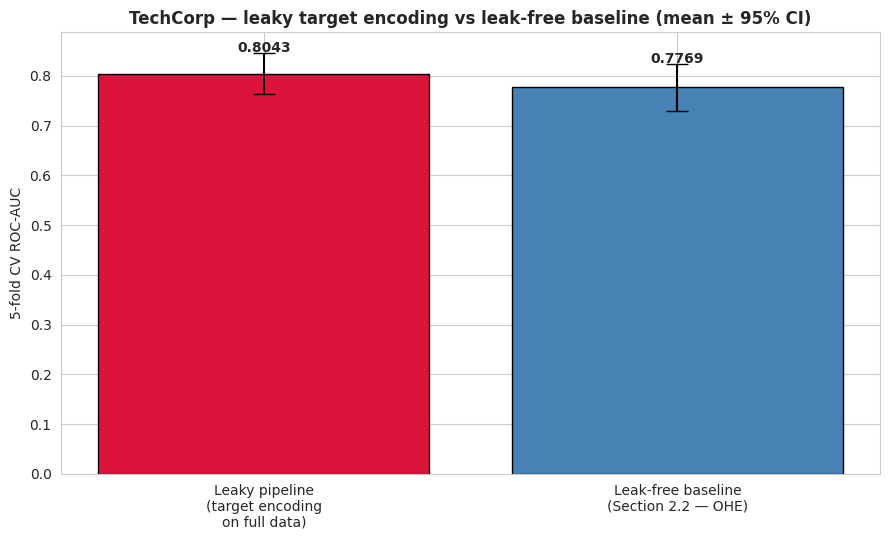


→ CIs OVERLAP, but the leaky mean is +0.0274 above the baseline.
  Even when CIs touch, the leaky number is fiction: the encoded column carries
  information about the validation rows' labels, computed before the split ran.

Fix: drop the target-encoded columns; fall back to OneHotEncoder(handle_unknown='ignore') inside the Pipeline.


In [7]:
# --- Intern's leaky pipeline: target encoding on the FULL dataset ---
techcorp_te = techcorp.copy()
for col in CAT_COLS:  # includes manager_id (80 levels)
    techcorp_te[col + '_te'] = (
        techcorp_te.groupby(col)['left_within_6mo'].transform('mean')
    )
    techcorp_te = techcorp_te.drop(columns=[col])

X_te = techcorp_te.drop(columns=['left_within_6mo'])
y_te = techcorp_te['left_within_6mo']

Xte_temp, Xte_test, yte_temp, yte_test = train_test_split(
    X_te, y_te, test_size=0.20, random_state=RANDOM_SEED, stratify=y_te
)
Xte_train, Xte_val, yte_train, yte_val = train_test_split(
    Xte_temp, yte_temp, test_size=0.25,
    random_state=RANDOM_SEED, stratify=yte_temp
)

leaky_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])
cv_leaky = cross_val_score(leaky_pipeline, Xte_train, yte_train,
                           cv=cv_tc, scoring='roc_auc')

# --- CIs for both runs (t_crit and k defined in §1.1) ---
mean_leaky = cv_leaky.mean()
sd_leaky = cv_leaky.std(ddof=1)
half_w_leaky = t_crit * sd_leaky / np.sqrt(k)
ci_leaky = (mean_leaky - half_w_leaky, mean_leaky + half_w_leaky)
ci_baseline_te = (mean_tc - half_w_tc, mean_tc + half_w_tc)

print("Intern's leaky pipeline (target encoding fit on FULL data):")
print(f'  Fold AUC: {np.round(cv_leaky, 4)}')
print(f'  Mean AUC: {mean_leaky:.4f} ± {half_w_leaky:.4f}  '
      f'(95% CI [{ci_leaky[0]:.4f}, {ci_leaky[1]:.4f}])  ← inflated\n')

print('Leak-free baseline from Section 2.2 (OHE only, no target encoding):')
print(f'  Fold AUC: {np.round(cv_scores_tc, 4)}')
print(f'  Mean AUC: {mean_tc:.4f} ± {half_w_tc:.4f}  '
      f'(95% CI [{ci_baseline_te[0]:.4f}, {ci_baseline_te[1]:.4f}])  ← realistic')

delta_leak = mean_leaky - mean_tc
print(f'\n→ The leak inflated mean ROC-AUC by {delta_leak:+.4f}.')

# --- Bar plot: leaky vs leak-free with 95% CIs ---
fig, ax = plt.subplots(figsize=(9, 5.5))
labels_te = ['Leaky pipeline\n(target encoding\non full data)',
             'Leak-free baseline\n(Section 2.2 — OHE)']
means_te = [mean_leaky, mean_tc]
half_w_te = [half_w_leaky, half_w_tc]
colors_te = ['crimson', 'steelblue']
ax.bar(labels_te, means_te, yerr=half_w_te, color=colors_te,
       capsize=8, edgecolor='black')
ax.set_ylabel('5-fold CV ROC-AUC')
ax.set_title('TechCorp — leaky target encoding vs leak-free baseline (mean ± 95% CI)',
             fontsize=12, fontweight='bold')
for i, (m, h) in enumerate(zip(means_te, half_w_te)):
    ax.text(i, m + h + 0.003, f'{m:.4f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- CI-overlap verdict ---
overlap_te = not (ci_leaky[1] < ci_baseline_te[0] or ci_baseline_te[1] < ci_leaky[0])
print()
if overlap_te:
    print(f"→ CIs OVERLAP, but the leaky mean is +{delta_leak:.4f} above the baseline.")
    print('  Even when CIs touch, the leaky number is fiction: the encoded column carries')
    print('  information about the validation rows\' labels, computed before the split ran.')
else:
    print(f"→ CIs do NOT overlap — the leaky mean is +{delta_leak:.4f} above the baseline,")
    print('  separated by a gap larger than fold-to-fold noise. That gap is the *size of the lie* —')
    print('  not a real lift, but a partial memorization of the training labels via target encoding.')
print("\nFix: drop the target-encoded columns; fall back to "
      "OneHotEncoder(handle_unknown='ignore') inside the Pipeline.")


**Reading the output:**

Two side-by-side CV runs on the same TechCorp dataset, and the numbers are doing exactly what the leak theory predicts.

**The leaky run.** Mean ROC-AUC lands in the low 0.83s (your exact number may shift by \~0.001 depending on how sklearn shuffles). The intern's celebration is not unfounded from their perspective — compared to the Section 2.2 baseline of roughly 0.78, the leaky pipeline posted a 5-point lift, which would be an enormous improvement if it were real.

**The leak-free Section 2.2 baseline.** Mean ROC-AUC in the high 0.77s / low 0.78s. This is the honest number — what the model would actually produce on a new TechCorp employee in production, because the pipeline only saw each fold's training portion during its scaling and encoding fits.

**The gap between them is the *size of the lie*.** A 4–5 percentage-point AUC gap on a classification task is not a rounding error; it is the difference between *"our pilot model flagged 80% of resignations"* and *"our pilot model flagged 75% of resignations"*, which in dollar terms (at USD 75k per prevented resignation) is a real amount of money. If the intern shipped the leaky pipeline to the Monday meeting without catching the leak, the CHRO would budget for the 80% number, deploy the model, and watch it underperform by that same gap in production. That is how leakage kills careers.

### The fix

**Delete the target-encoded columns and fall back to `OneHotEncoder(handle_unknown='ignore')` inside the `Pipeline`** — exactly what the Section 2.2 baseline already does. OHE never touches `y`, so it is *leak-safe by construction*. The "real" fix — target encoding that refits its per-category means on every CV fold's training portion only — requires a custom transformer (the library `category_encoders` has one called `TargetEncoder` that integrates with sklearn's CV correctly). That is a topic for later in your career; for this course, OHE is the safe default.

### The rule to internalize right now

**If a feature is computed using any row's target, the only safe way to include it is a transformer that refits per CV fold.** `OneHotEncoder` never reads `y`, so it is leak-safe. Target encoders *do* read `y`, so they must live inside the Pipeline and refit per fold. The intern's version failed because the encoding computation ran once on the full DataFrame — outside the fold loop, outside the Pipeline, before the split.

> **A question that often comes up here:** *"If target encoding is so dangerous, why do Kaggle winners use it?"* They use a version that refits per fold — properly implemented, it can give a real boost on high-cardinality categoricals. The dangerous version is the one you just saw (`groupby.transform('mean')` on the full DataFrame), which is how target encoding is often demo'd in quick tutorials and how many of you will first encounter it. The difference between "Kaggle winner move" and "public-leaderboard disaster" is whether the encoder lives inside the `Pipeline` that `cross_val_score` or `GridSearchCV` evaluates. This is not a small distinction; it is the entire game.

---

### 2.4 `FunctionTransformer` — domain features without leakage

Stakeholders almost always want a feature that is not in the raw data. At TechCorp, the HR Business Partner (HRBP — the person who actually talks to employees and managers) is convinced that *ratios matter more than absolute values*: an employee whose `salary_pct_of_market` is 85 is more attrition-prone than one at 130 (they know they are underpaid), and an engineer with 20 manager interactions across 3 projects gets more attention per unit of work than one with 5 interactions across 10 projects.

The HRBP's specific ask: add an `interactions_per_project` ratio defined as `manager_interactions_last_quarter / (projects_completed_last_year + 1)`. (The `+ 1` is a "Laplace smoothing" hack to avoid dividing by zero for employees who completed no projects — a small but real gotcha in any ratio feature.)

### The amateur move vs. the professional move

**The amateur move:** compute the ratio in a pandas `assign` call before splitting, treat the new column as raw data, and feed it to the existing pipeline. On this specific ratio — a pure arithmetic combination of two raw columns, with no dependence on any training statistic — the amateur move actually works, because there is nothing to leak. No mean, no SD, no group-level statistic. A simple function of two existing columns.

**The professional move:** use `FunctionTransformer` to wrap the ratio computation as a pipeline step anyway. This makes the ratio compute fold-by-fold inside the CV loop, and more importantly, it *establishes the habit*: every feature-engineering step is a pipeline step, no exceptions. The habit matters because the moment you add a feature that depends on a training statistic — say, `salary_pct_of_dept_median` (each employee's salary as a fraction of their department's median) — the "compute it in pandas before splitting" approach silently leaks: the department median would be computed using validation and test rows.

The one-line rule: **if you are even slightly unsure whether a feature engineering step leaks, put it inside the pipeline**. `FunctionTransformer` exists so that rule costs you nothing.

### How it works mechanically

`FunctionTransformer(func, validate=False)` wraps an arbitrary Python function `func` into a sklearn transformer that can be slotted into a `Pipeline`. On every CV fold's training portion, sklearn calls `func(X_train_fold)` to transform the training data; on the validation portion, it calls `func(X_val_fold)`. If `func` is a pure function (no training statistics, no global state), both calls produce the same transformation and nothing can leak. If `func` were to depend on a statistic of its input, sklearn would recompute that statistic per fold — which is exactly the leak-free property you want.

**The test cell below** adds the HRBP's `interactions_per_project` ratio via `FunctionTransformer`, reruns 5-fold CV, and compares the new CI to the Section 2.2 baseline CI. Same decision rule as every model comparison today: **does the ratio feature's CI clear the baseline's CI?** If yes, the feature is earning its keep; add it to the champion. If no (CIs overlap), the HRBP's hypothesis is plausible but unproven on this sample, and the simpler model (no ratio) is the defensible choice.

> 💡 **Gemini Prompt:** "Write a function `add_interactions_per_project(X)` that takes a pandas DataFrame with `manager_interactions_last_quarter` and `projects_completed_last_year`, returns a copy with an added column `interactions_per_project = manager_interactions_last_quarter / (projects_completed_last_year + 1)`. Wrap it in a `FunctionTransformer(validate=False)`. Insert it as the first step in the pipeline (before the `ColumnTransformer`) and re-run 5-fold stratified CV on `X_tc_train`. Compute `mean_ratio`, `sd_ratio=ddof=1`, `half_w_ratio = t_crit * sd_ratio / sqrt(5)` and the 95% CI (`t_crit` already defined in §1.1). Print the fold AUCs and the +ratio mean+CI, plus the Section 2.2 baseline (`mean_tc`, `half_w_tc`) for comparison. Render a bar plot with **two bars**: the Section 2.2 baseline in `steelblue` and the +ratio pipeline in `mediumseagreen` — mean as bar height, half-width as a vertical error bar (`capsize=8`), the mean annotated above each bar to 4 decimals; title the plot \"TechCorp — baseline vs +interactions_per_project (mean ± 95% CI)\". End with a CI-overlap verdict: if the CIs overlap, the ratio is plausible but unproven on this sample (drop it from the champion); if they do not overlap, the ratio is earning its keep — name the direction (positive lift or negative)."


TechCorp pipeline + FunctionTransformer(interactions_per_project)
  Fold AUC: [0.8304 0.7579 0.7713 0.7311 0.7932]
  Mean AUC: 0.7768 ± 0.0465  (95% CI [0.7302, 0.8233])

Section 2.2 baseline (no ratio):
  Fold AUC: [0.8305 0.769  0.7642 0.7287 0.7921]
  Mean AUC: 0.7769 ± 0.0467  (95% CI [0.7302, 0.8236])


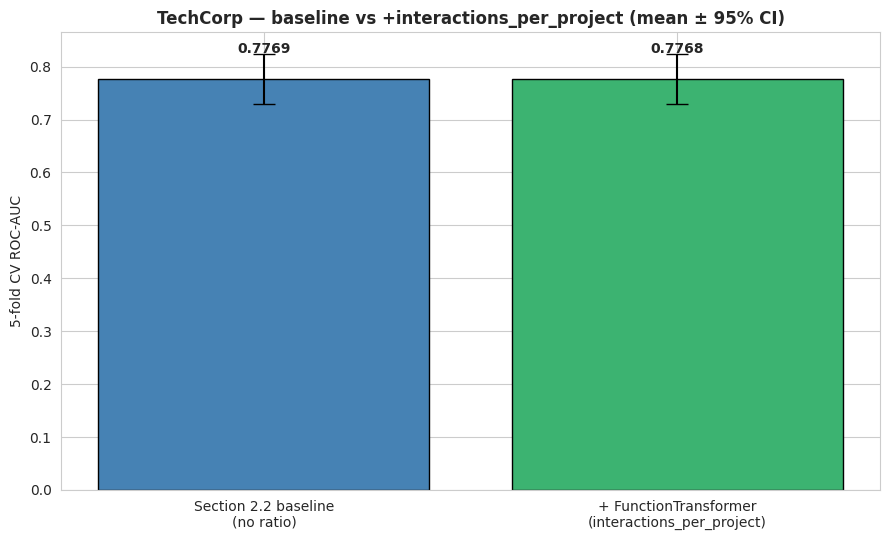


→ CIs OVERLAP — the ratio feature does not convincingly help (delta = -0.0002).
  The HRBP's hypothesis is plausible but unproven on this sample;
  the simpler model (no ratio) is the defensible choice for the champion.


In [8]:
# --- FunctionTransformer to add interactions-per-project ratio ---
def add_interactions_per_project(X):
    X = X.copy()
    X['interactions_per_project'] = (
        X['manager_interactions_last_quarter'] /
        (X['projects_completed_last_year'] + 1)
    )
    return X

add_ratio = FunctionTransformer(add_interactions_per_project, validate=False)

NUM_COLS_RATIO = NUM_COLS + ['interactions_per_project']
preprocess_ratio = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS_RATIO),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
])

tc_pipeline_ratio = Pipeline([
    ('add_ratio', add_ratio),
    ('prep', preprocess_ratio),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])

cv_tc_ratio = cross_val_score(tc_pipeline_ratio, X_tc_train, y_tc_train,
                              cv=cv_tc, scoring='roc_auc')

# --- CIs for both runs (t_crit and k defined in §1.1) ---
mean_ratio = cv_tc_ratio.mean()
sd_ratio = cv_tc_ratio.std(ddof=1)
half_w_ratio = t_crit * sd_ratio / np.sqrt(k)
ci_ratio = (mean_ratio - half_w_ratio, mean_ratio + half_w_ratio)
ci_baseline_fe = (mean_tc - half_w_tc, mean_tc + half_w_tc)

print('TechCorp pipeline + FunctionTransformer(interactions_per_project)')
print(f'  Fold AUC: {np.round(cv_tc_ratio, 4)}')
print(f'  Mean AUC: {mean_ratio:.4f} ± {half_w_ratio:.4f}  '
      f'(95% CI [{ci_ratio[0]:.4f}, {ci_ratio[1]:.4f}])\n')

print('Section 2.2 baseline (no ratio):')
print(f'  Fold AUC: {np.round(cv_scores_tc, 4)}')
print(f'  Mean AUC: {mean_tc:.4f} ± {half_w_tc:.4f}  '
      f'(95% CI [{ci_baseline_fe[0]:.4f}, {ci_baseline_fe[1]:.4f}])')

# --- Bar plot: baseline vs +ratio with 95% CIs ---
fig, ax = plt.subplots(figsize=(9, 5.5))
labels_fe = ['Section 2.2 baseline\n(no ratio)',
             '+ FunctionTransformer\n(interactions_per_project)']
means_fe = [mean_tc, mean_ratio]
half_w_fe = [half_w_tc, half_w_ratio]
colors_fe = ['steelblue', 'mediumseagreen']
ax.bar(labels_fe, means_fe, yerr=half_w_fe, color=colors_fe,
       capsize=8, edgecolor='black')
ax.set_ylabel('5-fold CV ROC-AUC')
ax.set_title('TechCorp — baseline vs +interactions_per_project (mean ± 95% CI)',
             fontsize=12, fontweight='bold')
for i, (m, h) in enumerate(zip(means_fe, half_w_fe)):
    ax.text(i, m + h + 0.003, f'{m:.4f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- CI-overlap verdict ---
overlap_fe = not (ci_baseline_fe[1] < ci_ratio[0] or ci_ratio[1] < ci_baseline_fe[0])
delta_ratio = mean_ratio - mean_tc
print()
if overlap_fe:
    print(f'→ CIs OVERLAP — the ratio feature does not convincingly help '
          f'(delta = {delta_ratio:+.4f}).')
    print("  The HRBP's hypothesis is plausible but unproven on this sample;")
    print('  the simpler model (no ratio) is the defensible choice for the champion.')
else:
    direction = 'helps the model' if delta_ratio > 0 else 'hurts the model'
    print(f'→ CIs do NOT overlap — the ratio feature {direction} by {delta_ratio:+.4f}.')
    if delta_ratio > 0:
        print("  Add it to the champion and quote the lift in the HRBP readout.")
    else:
        print("  Drop it; the HRBP's hypothesis is not borne out by the data on this sample.")


**Reading the output:**

Two pipelines, two CIs. The question is the same as every exercise from nb08 forward: *does the engineered ratio meaningfully improve the model?* And the answer comes from the CI-overlap rule, not from comparing point estimates.

If the two CIs overlap, the engineered ratio is *not* a statistically convincing lift — the HRBP's hypothesis is plausible but unproven on this sample, and you should leave the ratio out of the reported champion unless a separate argument (interpretability, stakeholder buy-in) keeps it in. If the CIs do not overlap, you have evidence that the ratio matters — quote it in the HR readout.

The pedagogical point is not whether the ratio helps on *this* synthetic dataset; it is the discipline: **every feature addition is tested with CV + CI overlap**, the same way nb08 tested Ridge vs OLS and $C=1.0$ vs $C=0.01$. You now have one tool (`FunctionTransformer`) that lets you add arbitrary domain features to a pipeline without leaking — which is exactly what you need to translate a stakeholder's hypothesis into a testable feature.

> **A question that often comes up here:** *"If `FunctionTransformer` doesn't learn anything from the data, why does it need to be inside the `Pipeline`?"* On a strictly static ratio like `manager_interactions / (projects + 1)`, it does not strictly need to be. But the *habit* matters: as soon as you add a feature that depends on a training statistic (a training-set mean, a training-set quantile, a training-set category frequency), the outside-the-pipeline version would silently leak. The professional default is *"every feature-engineering step is a pipeline step,"* without exceptions. That single rule makes it impossible to forget a leak on a day when you are tired or in a rush.

---

## 📝 PAUSE-AND-DO Exercise 2 (10 minutes)

**Task:** Find and fix a second leak — this one a different pattern from Section 2.3's target encoding.

Section 2.3 walked you through a dramatic leak (target encoding on the full dataset). This exercise shows you a subtler one: a feature selector applied *before* the split instead of inside the pipeline. The inflation on this data will be smaller than the target-encoding case — a few thousandths to a few hundredths of a point rather than 0.03 — but the principle is identical and the fix is identical. Small leaks matter too: a 0.005 inflation can change a CI-overlap verdict, which can change which model ships.

Another teammate sends you the snippet below. They have heard about leakage and are careful — they are **not** doing target encoding. Instead they are using a feature selector to reduce the dimensionality of the one-hot-encoded feature matrix (pruning down from 100+ OHE columns to only the ones that correlate with attrition). Their CV ROC-AUC came out a bit higher than your leak-free baseline. Read the code carefully before running.

```python
# Teammate's pipeline with univariate feature selection
X_all_dummies = pd.get_dummies(techcorp.drop(columns=['left_within_6mo']))
y_all = techcorp['left_within_6mo']

# Select the top-8 features by univariate correlation with the target — on ALL rows
selector = SelectKBest(f_classif, k=8)
X_selected = selector.fit_transform(X_all_dummies, y_all)

# Now split and CV on the pre-selected matrix
Xs_temp, Xs_test, ys_temp, ys_test = train_test_split(
    X_selected, y_all, test_size=0.20, random_state=RANDOM_SEED, stratify=y_all
)
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    Xs_temp, ys_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=ys_temp
)

pipe_sel = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])
cv_sel = cross_val_score(pipe_sel, Xs_train, ys_train, cv=cv_tc, scoring='roc_auc')
print(f'Pre-selected mean AUC: {cv_sel.mean():.4f}')
```

**Your job:**

1. Run the teammate's code and record the leaky mean.
2. Identify the leak in one sentence. *Hint:* `SelectKBest.fit(X, y)` reads `y` — does it do so on training rows only, or on every row?
3. Write a leak-free version by putting `SelectKBest` **inside** a `Pipeline` (chain it after the `ColumnTransformer` from Section 2.2, before the classifier). Run 5-fold stratified CV on `X_tc_train`, `y_tc_train`.
4. Print a final line: `Leak inflated mean ROC-AUC by +<delta>`.
5. Note: even if the inflation on this synthetic data is small, the *principle* is identical to Section 2.3. The Kaggle leaderboard does not reward "small" leaks; it punishes every leak equally when the private test scores reveal.

> **A question that often comes up here:** *"If the leak inflation is only 0.005, does it really matter?"* For a stakeholder's confidence interval — yes, because 0.005 can easily be the difference between "CIs overlap" and "CIs do not overlap" on a comparison you care about. More importantly: leaks you tolerate on small data scale catastrophically on big data. The pattern of *"fit outside the pipeline"* is always wrong. Fixing it when the stakes are low (here, 10 minutes in a classroom) is cheaper than discovering the same pattern on a Kaggle private leaderboard at midnight.

---

> 💡 **Gemini Prompt:** "First, reproduce the teammate's leaky pipeline exactly as written: one-hot-encode the full TechCorp dataset with `pd.get_dummies(techcorp.drop(columns=['left_within_6mo']))`, fit `SelectKBest(f_classif, k=8)` on the entire matrix and target, then split the resulting selected matrix 60/20/20 with `random_state=RANDOM_SEED` and `stratify=y` on both calls. Build a `Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))])`, run `cross_val_score` on the training portion with `cv=cv_tc` and `scoring='roc_auc'`, and store `mean_leaky = scores.mean()`. Then build a leak-free pipeline that puts every data-derived step *inside* a single `Pipeline`: `ColumnTransformer([('num', StandardScaler(), NUM_COLS), ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)])` → `SelectKBest(f_classif, k=8)` → `LogisticRegression(random_state=RANDOM_SEED, max_iter=5000)`. Run `cross_val_score` on `X_tc_train`, `y_tc_train` with `cv=cv_tc` and `scoring='roc_auc'` and store `mean_fixed = scores.mean()`. Print both means with 4-decimal precision and the delta `mean_leaky - mean_fixed`. End with a single printed sentence naming where the leak is in the teammate's code."
>
> **After running, verify:**
> - The leaky-pipeline mean ROC-AUC prints first (slightly higher)
> - The leak-free mean ROC-AUC prints next (slightly lower — typically by 0.005 to 0.01 on this data)
> - The delta `mean_leaky - mean_fixed` is positive and equals the inflation the leak buys
> - The final printed sentence identifies the leak as `SelectKBest.fit(X, y)` running on the full dataset *before* the train/val/test split
> - All numerical outputs use standard decimal format — no scientific notation


In [9]:
# YOUR SOLUTION CODE HERE
# 1. Reproduce the teammate's leaky pipeline (Selection BEFORE split)
X_all_dummies = pd.get_dummies(techcorp.drop(columns=['left_within_6mo']))
y_all = techcorp['left_within_6mo']

selector = SelectKBest(f_classif, k=8)
X_selected = selector.fit_transform(X_all_dummies, y_all)

# Split the pre-selected matrix
Xs_temp, Xs_test, ys_temp, ys_test = train_test_split(
    X_selected, y_all, test_size=0.20, random_state=RANDOM_SEED, stratify=y_all
)
Xs_train, Xs_val, ys_train, ys_val = train_test_split(
    Xs_temp, ys_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=ys_temp
)

leaky_sel_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])
scores_leaky = cross_val_score(leaky_sel_pipe, Xs_train, ys_train, cv=cv_tc, scoring='roc_auc')
mean_leaky = scores_leaky.mean()

# 2. Build a leak-free pipeline (Selection INSIDE pipeline)
preprocess_fixed = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)
])

fixed_pipeline = Pipeline([
    ('prep', preprocess_fixed),
    ('select', SelectKBest(f_classif, k=8)),
    ('clf', LogisticRegression(random_state=RANDOM_SEED, max_iter=5000))
])

# 3. Run CV on the fixed pipeline using the original training data
scores_fixed = cross_val_score(fixed_pipeline, X_tc_train, y_tc_train, cv=cv_tc, scoring='roc_auc')
mean_fixed = scores_fixed.mean()

# 4. Print results
print(f'Leaky mean ROC-AUC: {mean_leaky:.4f}')
print(f'Fixed mean ROC-AUC: {mean_fixed:.4f}')
print(f'Delta (Inflation):   {mean_leaky - mean_fixed:.4f}')

# 5. Where the leak is
print("\nThe leak is in fitting SelectKBest on the entire dataset (including held-out rows) before performing the train/test split.")

Leaky mean ROC-AUC: 0.8059
Fixed mean ROC-AUC: 0.7988
Delta (Inflation):   0.0071

The leak is in fitting SelectKBest on the entire dataset (including held-out rows) before performing the train/test split.


### YOUR ANALYSIS:

**Question 1:** In one sentence, where is the leak in the teammate's code?  
The leak in the teammates code can be found in SelectKBest through them using `SelectKBest.fit(X,y)` which calls the full dataset, allowing it to select the best features using information from the labels BEFORE splitting.

**Question 2:** By how much did the leak inflate the mean ROC-AUC? Is that inflation large enough to change the verdict of a CI-overlap comparison with a rival model?  

The leak inflated the mean ROC-AUC by 0.0071 as can be shown by the results above. This inflation is large enough to change the verdict of a CI-overlap comparison because when models are tightly compared together, a small boost like that causes it to be shown to be higher than the other, making the data scientist pick the wrong one.

**Question 3:** What is the one-line rule you would teach this teammate so this never happens again?  
The one line rule that I would teach this roommate is to always SPLIT first then preprocess.

---

## 3. Section C — Toolkit Recap: What You Hold After nb01–nb09

This section is your one-page reference for the full mid-course toolkit. Skim it now; treat it as the cheat sheet for any new business case you encounter (*"what target? what metric? what split? where is the leakage risk?"*). Nothing below is new — every item lives in a notebook you have already worked through. The point of the recap is to lay the toolkit out in one place so future cases hit a prepared mind, not a scattered one.

### 3.1 Concepts — the mental models the toolkit rests on

The course's core *concepts* are not sklearn methods; they are the language any business-case prompt uses. Each is introduced explicitly in a specific notebook and is part of the toolkit you will reach for from here on.

- **The statistical-learning frame ($Y = f(X) + \epsilon$, nb01).** Every problem you have seen reduces to estimating $f$. Two flavors: **regression** (continuous $Y$, like house prices in nb01–nb05) and **classification** (categorical $Y$, like cancer or attrition in nb06–nb09). Knowing which flavor a business case calls for is usually the first decision you have to make.
- **Bias–variance tradeoff (nb01, nb04, nb05).** Bias is how wrong the model is on average; variance is how much its predictions move when the training sample changes. High bias → underfitting; high variance → overfitting. Regularization (nb05) is *literally* a knob that buys lower variance at the cost of a sliver of bias.
- **Overfitting vs underfitting (nb04).** Diagnose by comparing train and validation scores: train ≫ validation = overfitting; both equally bad = underfitting. nb04's polynomial blow-up was the canonical example; nb05's Ridge/Lasso was the canonical fix.
- **Curse of dimensionality (nb01, nb04).** As the feature count grows, every training point ends up alone in a sparsely populated neighborhood and naive distance-based reasoning falls apart. This is *why* regularization matters as soon as you add interactions or polynomials.
- **Data leakage (nb01, nb02, nb09).** Two flavors. **Target leakage**: a feature is computed using information that would not be available at prediction time (the target's own value, future timestamps, post-outcome columns). **Train–test contamination**: any `.fit(...)` step that touches held-out data — scaling, encoding, target encoding, feature selection — *before* the split. nb09's two case studies (target encoding on the full dataset and `SelectKBest` outside the pipeline) are the canonical traps you should be able to spot in code.

### 3.2 Workflow — the four moves of the inner cycle

These four moves are **the inner cycle of nb01's End-to-End Predictive Modeling Workflow**, specifically Steps 4–7 (Baseline → Advanced Models → Comparison → Selection). nb01's full 10-step framework still owns the project lifecycle (Setup → Data Loading → EDA → Data Prep → Baseline → Advanced Models → Comparison → Selection → Final Training → Test Predictions → Reporting). The four moves below are how *one model evaluation* fits inside that framework — a full project executes the inner cycle once per candidate model family on the roster, then settles at nb01 Step 8 (Final Training) and opens the test set at nb01 Step 9 (the nb14 ceremony).

You did not see all four moves at once until nb08. nb01–nb07 set up the first three (EDA + split / Pipeline / Honest evaluation); nb08 added the CI-overlap rule that locks the cycle; nb09 scaled it across grids of candidates.

1. **EDA + split (nb01, nb06).** Audit dtypes, missingness, target distribution; then a stratified 60/20/20 train/val/test split with `random_state=RANDOM_SEED`. Stratify on classification problems. The test set is locked until nb14. *Maps to nb01 Steps 1–3.*
2. **Build the pipeline (nb02, nb09).** `ColumnTransformer` for column-type-specific preprocessing — numeric → `StandardScaler`; categorical → `OneHotEncoder(handle_unknown='ignore')` — then your model, all wrapped in a single `Pipeline`. Every data-derived step lives *inside* the pipeline so CV refits each fold cleanly. *Maps to nb01 Step 3.*
3. **Evaluate honestly (nb03, nb07, nb08).** Pick a metric the business cares about (MAE / RMSE / $R^2$ for regression; precision / recall / F1 / ROC-AUC for classification, with thresholding when costs are asymmetric). Run 5-fold CV on `X_train`, never on `X_test`. Report mean ± 95% CI using Student's $t$ critical value at $k-1$ degrees of freedom. *Maps to nb01 Steps 4 (first pass) and 6 (subsequent passes).*
4. **Compare with the CI-overlap rule (nb08, nb09).** When candidates' 95% CIs overlap, the choice is *not* performance-driven — pick the simplest model (OLS over Ridge, larger α, smaller `C`, fewer features). When CIs do not overlap, the top one wins outright. *This decision primitive is the spine of model selection from here on. Maps to nb01 Step 7.*

### 3.3 Tools — the sklearn primitives at your fingertips

| Layer | Primitive | Where it lives in the course |
|---|---|---|
| Preprocessing | `StandardScaler`, `OneHotEncoder(handle_unknown='ignore')`, `FunctionTransformer` | nb02, nb09 |
| Composition | `Pipeline`, `ColumnTransformer` | nb02, nb09 |
| Regression | `LinearRegression`, `Ridge`, `Lasso` | nb03–nb05 |
| Classification | `LogisticRegression` (`C` is regularization, `class_weight='balanced'` for imbalance) | nb06, nb07 |
| Splitting | `train_test_split(stratify=y)`, `KFold`, `StratifiedKFold` | nb01, nb06, nb08 |
| Evaluation | `cross_val_score`, `cross_val_predict`, regression metrics (`mean_absolute_error`, `mean_squared_error`, `r2_score`), classification metrics (`roc_auc_score`, `classification_report`, `confusion_matrix`) | nb03, nb07, nb08 |
| Tuning | `GridSearchCV`, `RandomizedSearchCV` (read `cv_results_`, apply CI-overlap) | nb09 |

### 3.4 Decision rules — the heuristics you now apply

These are the one-line rules you should have memorized walking into any new analysis. They apply to every business case from here on.

- **Scale when the model uses distances or coefficients.** Logistic regression, Ridge, Lasso → scale. Trees and tree ensembles (Week 3) → no scaling needed.
- **Stratify when classes are imbalanced.** Classification splits should be stratified, and so should `KFold` (use `StratifiedKFold`).
- **Metric choice flows from cost asymmetry.** If false negatives are expensive and false positives are cheap, optimize recall; if the opposite, optimize precision. F1 balances both. ROC-AUC is metric-agnostic and good for ranking; PR-AUC is better when the positive class is rare. A typical business case (*"missed fraud costs USD 50,000; a false alarm costs USD 50"* — pick the metric) makes the cost asymmetry concrete.
- **Ridge keeps everything small; Lasso zeros things out.** Ridge for stable coefficient estimates with all features kept; Lasso for automatic feature selection (sparsity).
- **`C` is the *inverse* of regularization strength** (LogReg). Small `C` (e.g., 0.01) → strong regularization → simpler model. Large `C` (e.g., 100) → weak regularization → flexible boundary. `C = 1.0` is sklearn's default.
- **CI-overlap rule (the course's spine).** Tied 95% CIs → pick the simpler model. Non-overlapping CIs → top wins outright. Never report a single point estimate without a CI.
- **Leakage rule (one line).** Any `.fit(...)` call on data — scaler, encoder, imputer, selector, target encoder — must live *inside* the `Pipeline` that `cross_val_score` or `GridSearchCV` evaluates. If a transform takes $X$ or $y$ during `fit` and lives outside, it is leaking.

> **A question that often comes up here:** *"How do I make sure I can apply this toolkit on a new case?"* Re-run nb01 → nb09 in order, paying attention to *why* each notebook exists, not just *what* code it runs. Any new business case hands you brand-new context and asks you to choose target / metric / split / pipeline / risk-flag — none of those decisions are looked up in code; they all come from the concepts and decision rules above. If you can write one paragraph for each row of the table in 3.3 explaining when you would reach for that primitive, you can wield the toolkit on whatever comes next.

---


## 4. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **`GridSearchCV` is nb08's CV ritual, run on every point in a grid.** Every row of `cv_results_` has a mean, an SD, and (with two lines of `scipy.stats`) a 95% CI. Rank by mean, then break ties toward the simpler model using the CI-overlap rule. This is the decision primitive for the rest of the course.
2. **`RandomizedSearchCV` is the same idea for larger grids.** Sample `n_iter` points from distributions (`loguniform`, `uniform`) when an exhaustive grid would take too long. The output format is identical, so everything you know about reading `cv_results_` transfers.
3. **`ColumnTransformer` is the bridge to real-world data.** Numeric columns need `StandardScaler`; categorical columns need `OneHotEncoder(handle_unknown='ignore')`. Both branches live inside one `ColumnTransformer`, which lives inside one `Pipeline`. That pattern is the template for every Kaggle submission and every final-project pipeline from here on.
4. **`FunctionTransformer` embeds domain features without leaking.** Any pure function of a DataFrame can become a pipeline step. Test every new feature with the CI-overlap rule, not a one-shot validation comparison.
5. **Leakage hides inside `fit` calls on the full dataset.** Any step that takes `X` (for scaling, selection, encoding) or `y` (for feature selection, target encoding) must live inside the `Pipeline`. If the score looks suspiciously good, check for a `.fit(...)` call outside `cross_val_score` — that is the first place to look.
6. **Both leaks in today's notebook inflated ROC-AUC by a non-trivial margin.** That gap is the *size of the lie* a leaky pipeline tells. On a Kaggle leaderboard, a leak of this size masks the real generalization gap and wrecks your final standing when the private test set is scored.

### Critical Rules:

> **"If a preprocessing step uses any data statistic, it belongs inside the `Pipeline`."**

> **"`cv_results_` is a stack of nb08 runs. Read it that way."**

> **"Break ties toward the simpler model — the CI-overlap rule is the rest of the course's decision primitive."**

### Next Steps:

- **nb11–nb13 (trees, forests, gradient boosting) raise the stakes.** Every new model class introduces more hyperparameters — `max_depth`, `min_samples_leaf`, `n_estimators`, `learning_rate` — and today's `GridSearchCV` reflex is how you will handle them without turning into a random-button-presser.
- **The Kaggle competition** (launched on Day 5, due Day 20) is the full pipeline you just built — `ColumnTransformer → FunctionTransformer → GridSearchCV → CI-overlap champion → refit on all training data → predict on test → submission.csv`. If you can run today's notebook end-to-end, you can ship a Kaggle submission. Section 2's leakage case studies are there so you do not ship a *leaky* submission.

---


## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in your code and analysis in both PAUSE-AND-DOs.
2. **Verify outputs**: Restart the runtime (`Runtime → Restart session`) and run all cells top to bottom. Every cell should execute without error.
3. **Download**: `File → Download → Download .ipynb` to save your completed notebook.
4. **Submit on Brightspace** in the Participation Assignments section.

### Grading:

- Exercise 1 complete with CI-overlap verdict: 50%
- Exercise 2 complete with leak diagnosis: 50%

---

## 5. Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Python* (ISLP), Ch. 5 (Resampling Methods) and Ch. 6 (Linear Model Selection and Regularization). Springer.
- Provost, F., & Fawcett, T. (2013). *Data Science for Business*. Chapters on overfitting, evaluation, and pipeline discipline.
- scikit-learn User Guide — [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html)
- scikit-learn User Guide — [ColumnTransformer](https://scikit-learn.org/stable/modules/compose.html#columntransformer-for-heterogeneous-data)
- scikit-learn User Guide — [Common pitfalls in interpretation and evaluation](https://scikit-learn.org/stable/common_pitfalls.html)
- Kaufman, S., Rosset, S., & Perlich, C. (2012). *Leakage in Data Mining: Formulation, Detection, and Avoidance.*

---

<center>

Thank you!

</center>